In [1]:
#pip install xgboost

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import os 

from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, roc_curve, accuracy_score, f1_score, recall_score, precision_score, ConfusionMatrixDisplay 
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.experimental import enable_iterative_imputer  # regression imputation
from sklearn.impute import IterativeImputer, SimpleImputer

#models 
from sklearn.svm import SVC
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier


## Load dataset

In [3]:
#train data 
mri_data = pd.read_csv("TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")
cat_data = pd.read_excel("TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx")
quant_data = pd.read_excel("TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx")

#test data 
mri_test = pd.read_csv("TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")
cat_test = pd.read_excel("TEST/TEST_CATEGORICAL.xlsx")
quant_test = pd.read_excel("TEST/TEST_QUANTITATIVE_METADATA.xlsx")

In [4]:
mri_data.shape, cat_data.shape, quant_data.shape

((1213, 19901), (1213, 10), (1213, 19))

In [5]:
mri_test.shape, cat_test.shape, quant_test.shape

((304, 19901), (304, 10), (304, 19))

In [6]:
y_data = pd.read_excel("TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")
y_data.shape

(1213, 3)

### Target Variables 
**Target Variables**
  - ADHD diagnosis status (ADHD_Outcome)
  - Biological sex (Sex_F)

### Feature Variables 
**Brain Connectivity Data**
  - fMRI connectome matrices (~19,900 features)
  - Brain region correlation values

**Psychological Assessment Scores**
  - Strength and Difficulties Questionnaire (SDQ) - 9 scores
  - Measures of emotional problems, behavioral issues, hyperactivity, peer problems

**Parenting Measures**
  - Alabama Parenting Questionnaire (APQ) - 6 scores
  - Parental discipline, involvement, monitoring styles

**Clinical Measures**
  - Handedness (Edinburgh Handedness Questionnaire)
  - Color vision ability

**Demographic Information**
  - Enrollment year
  - Study site location
  - Child's ethnicity and race
  - Parent's education level


## EDA

### Quantitative Metadata

#### Strength and Difficulties Questionnaire (SDQ)

| Feature | Format | Range | Example | Description |
|:--------|:-------|:------|:--------|:------------|
| **SDQ_SDQ_Conduct_Problems** | Integer | 0-10 | 3 | Measures behavior issues like fighting, lying, disobedience. A score of 3 indicates moderate behavioral problems. |
| **SDQ_SDQ_Difficulties_Total** | Integer | 0-40 | 17 | Overall score combining all problem areas. A score of 17 would indicate moderate overall difficulties. |
| **SDQ_SDQ_Emotional_Problems** | Integer | 0-10 | 4 | Measures anxiety, worry, sadness. A score of 4 indicates some emotional challenges. |
| **SDQ_SDQ_Externalizing** | Integer | 0-20 | 12 | Combines conduct problems and hyperactivity scores. A score of 12 suggests significant "acting out" behaviors. |
| **SDQ_SDQ_Generating_Impact** | Integer | 0-10 | 5 | Measures how problems affect daily life. A score of 5 means these issues moderately impact the child's functioning. |
| **SDQ_SDQ_Hyperactivity** | Integer | 0-10 | 8 | Measures restlessness, concentration issues, impulsivity. A score of 8 indicates high levels of hyperactive behavior. |
| **SDQ_SDQ_Internalizing** | Integer | 0-20 | 7 | Combines emotional and peer problems. A score of 7 indicates moderate internal struggles. |
| **SDQ_SDQ_Peer_Problems** | Integer | 0-10 | 3 | Measures friendship difficulties. A score of 3 suggests some challenges with peer relationships. |
| **SDQ_SDQ_Prosocial** | Integer | 0-10 | 7 | Measures positive social behaviors. A score of 7 indicates good prosocial skills. |

#### Alabama Parenting Questionnaire (APQ)

| Feature | Format | Range | Example | Description |
|:--------|:-------|:------|:--------|:------------|
| **APQ_P_APQ_P_CP** | Integer | 0-12 | 4 | Corporal Punishment Score. A score of 4 indicates moderate use of physical discipline. |
| **APQ_P_APQ_P_ID** | Integer | 0-28 | 13 | Inconsistent Discipline Score. A score of 13 suggests moderately inconsistent rule enforcement. |
| **APQ_P_APQ_P_INV** | Integer | 0-50 | 40 | Involvement Score. A score of 40 indicates high parental engagement. |
| **APQ_P_APQ_P_OPD** | Integer | 0-28 | 18 | Other Discipline Practices Score. A score of 18 indicates moderate use of alternative discipline approaches. |
| **APQ_P_APQ_P_PM** | Integer | 0-37 | 16 | Poor Monitoring/Supervision Score. A score of 16 suggests moderate lack of parental oversight. |
| **APQ_P_APQ_P_PP** | Integer | 0-30 | 25 | Positive Parenting Score. A score of 25 indicates strong use of positive reinforcement. |

#### Other Clinical Measures

| Feature | Format | Range | Example | Description |
|:--------|:-------|:------|:--------|:------------|
| **EHQ_EHQ_Total** | Float | -100 to +100 | 76.67 | Edinburgh Handedness score. A score of 76.67 indicates strong right-handedness. |
| **ColorVision_CV_Score** | Integer | 0-14 | 14 | Color vision test score. A perfect score of 14 indicates normal color vision. |


In [7]:
quant_data.describe() #ehq score range seems to out of scale compared to other measurements

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
count,1200.000000,1190.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,853.000000
mean,59.514750,13.419328,3.819317,13.337219,39.767694,17.963364,16.557036,25.498751,2.074751,12.213455,2.324751,7.613787,4.103821,5.539037,4.599668,2.274917,7.740864,11.245678
std,49.744631,2.112830,1.330348,3.593562,4.872729,3.333965,5.146548,3.053720,2.022992,6.517330,2.166399,4.130399,2.808079,2.807063,3.510469,2.089041,2.094832,3.234372
min,-100.000000,0.000000,2.000000,5.000000,23.000000,7.000000,5.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46.670000,14.000000,3.000000,11.000000,36.000000,16.000000,13.000000,23.000000,0.000000,7.000000,1.000000,5.000000,2.000000,4.000000,2.000000,0.000000,6.000000,8.803901
50%,77.800000,14.000000,3.000000,13.000000,40.000000,18.000000,16.000000,26.000000,2.000000,12.000000,2.000000,8.000000,4.000000,6.000000,4.000000,2.000000,8.000000,10.739219
75%,94.470000,14.000000,4.000000,16.000000,43.000000,20.000000,19.000000,28.000000,3.000000,17.000000,4.000000,10.000000,6.000000,8.000000,7.000000,4.000000,10.000000,13.460871
max,100.000000,14.000000,12.000000,28.000000,50.000000,28.000000,37.000000,30.000000,10.000000,34.000000,10.000000,20.000000,10.000000,10.000000,17.000000,9.000000,10.000000,21.564453


In [8]:
quant_data.isnull().sum() #missing data problem need to be addressed later

participant_id                  0
EHQ_EHQ_Total                  13
ColorVision_CV_Score           23
APQ_P_APQ_P_CP                 12
APQ_P_APQ_P_ID                 12
APQ_P_APQ_P_INV                12
APQ_P_APQ_P_OPD                12
APQ_P_APQ_P_PM                 12
APQ_P_APQ_P_PP                 12
SDQ_SDQ_Conduct_Problems        9
SDQ_SDQ_Difficulties_Total      9
SDQ_SDQ_Emotional_Problems      9
SDQ_SDQ_Externalizing           9
SDQ_SDQ_Generating_Impact       9
SDQ_SDQ_Hyperactivity           9
SDQ_SDQ_Internalizing           9
SDQ_SDQ_Peer_Problems           9
SDQ_SDQ_Prosocial               9
MRI_Track_Age_at_Scan         360
dtype: int64

In [9]:
quant_variables = quant_data.columns[quant_data.columns!="participant_id"]

quant_y_df = pd.merge(quant_data, y_data, on='participant_id')
quant_y_df.shape

(1213, 21)

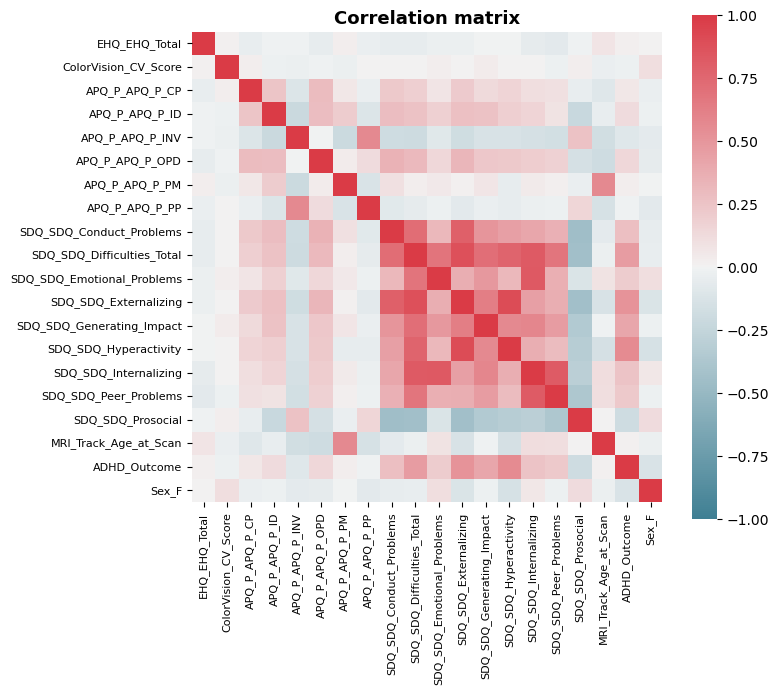

In [10]:
#correlation matrix
plt.figure(figsize=(8,7))

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(quant_y_df[quant_y_df.columns[quant_y_df.columns!="participant_id"]].corr(), vmax=1, vmin=-1, square=True, center=0, cmap=cmap) 

plt.title('Correlation matrix', fontweight='bold', fontsize=13)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

#### Visualization 1 : Strength & Difficulties Questionnaire

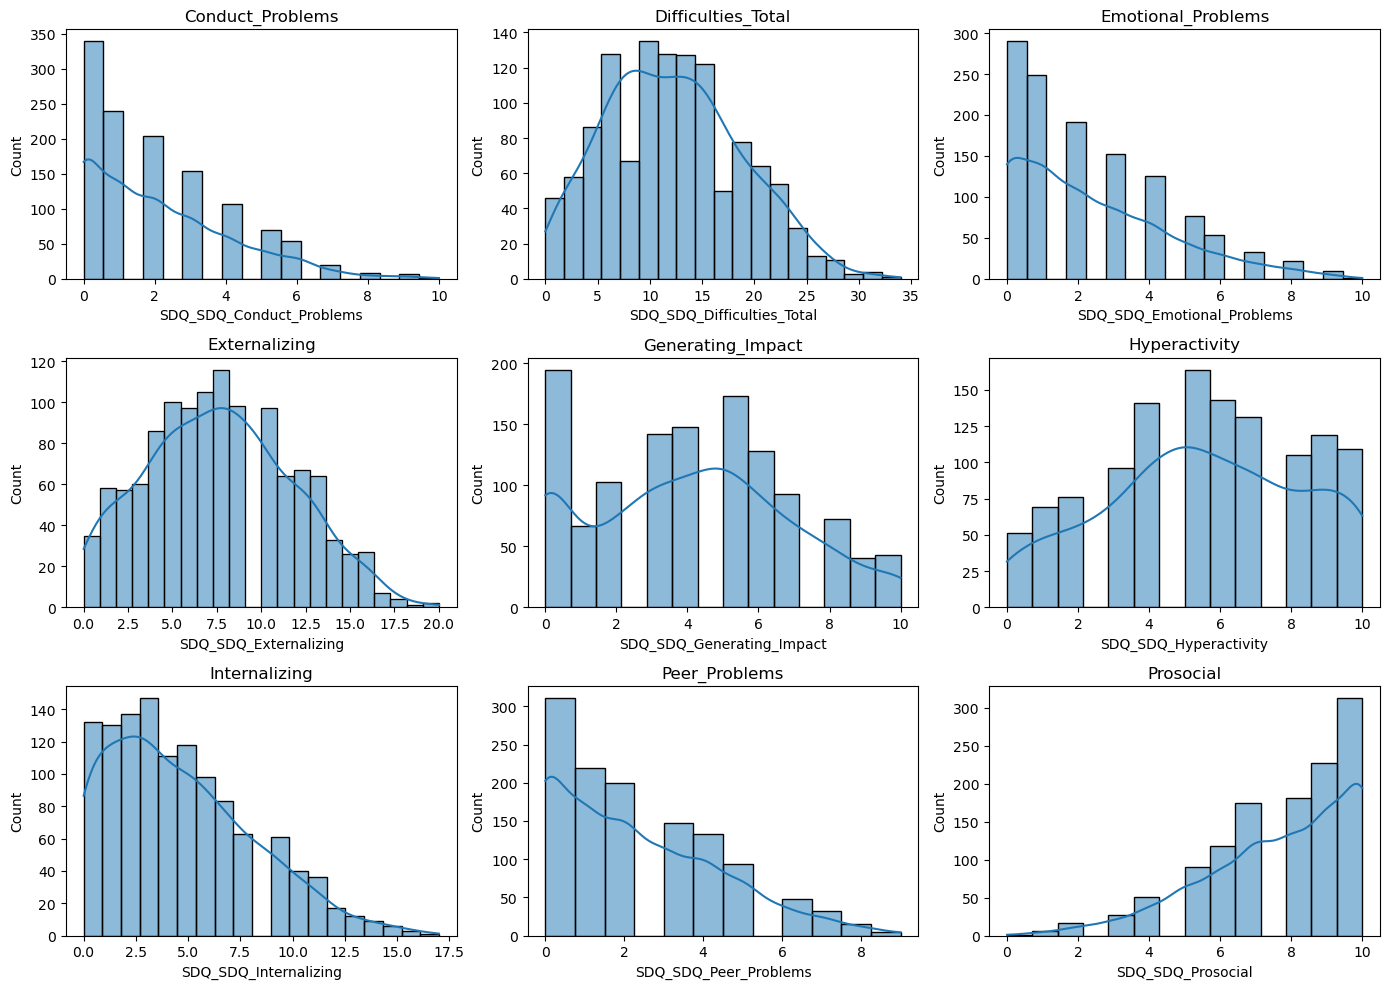

In [11]:
sdq_vars = [col for col in quant_data.columns if col.startswith('SDQ')]

plt.figure(figsize=(14, 10))
for i, var in enumerate(sdq_vars):
    plt.subplot(3, 3, i+1)
    sns.histplot(quant_data[var], kde=True)
    plt.title(var.split('SDQ_SDQ_')[1])
plt.tight_layout()
plt.show()

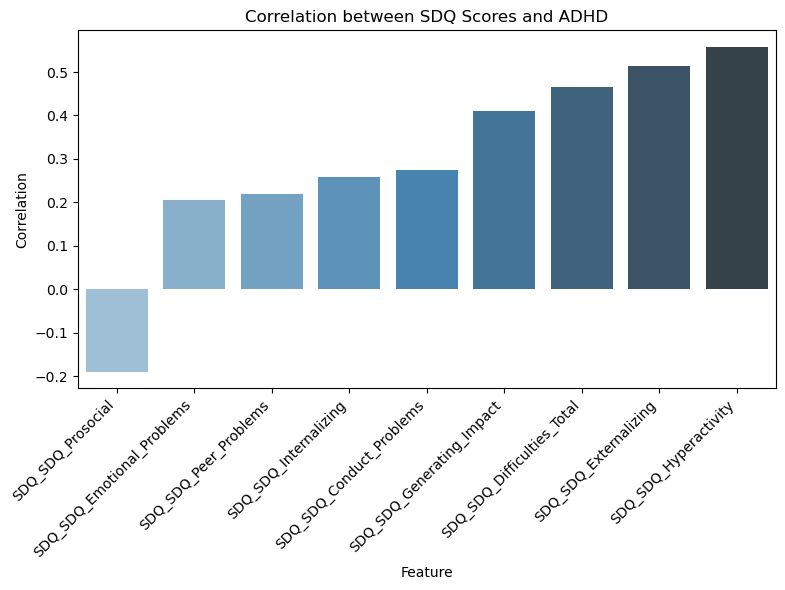

In [12]:
# Correlation with ADHD
plt.figure(figsize=(8, 6))

sdq_adhd_corr = quant_y_df[sdq_vars + ['ADHD_Outcome']].corr()['ADHD_Outcome'].drop('ADHD_Outcome').sort_values()
df_corr = pd.DataFrame(list(sdq_adhd_corr.items()), columns=['Feature', 'Correlation'])
sns.barplot(data=df_corr, x='Feature', y='Correlation', palette='Blues_d')

plt.title('Correlation between SDQ Scores and ADHD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

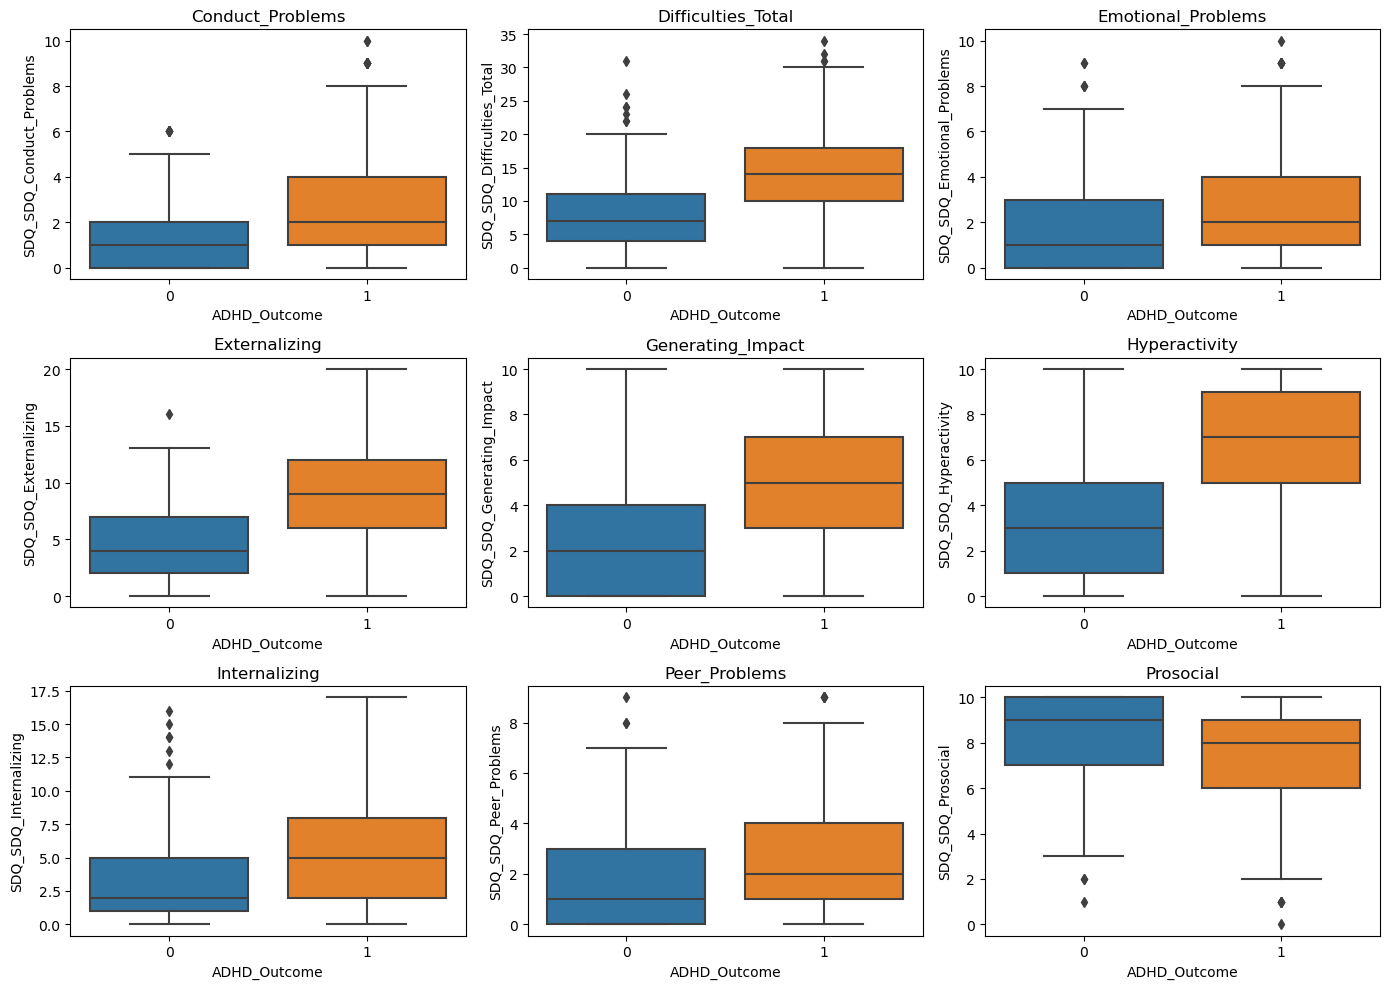

In [13]:
# Box plots by ADHD diagnosis
plt.figure(figsize=(14, 10))
for i, var in enumerate(sdq_vars):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='ADHD_Outcome', y=var, data=quant_y_df)
    plt.title(var.split('SDQ_SDQ_')[1])
plt.tight_layout()
plt.show()

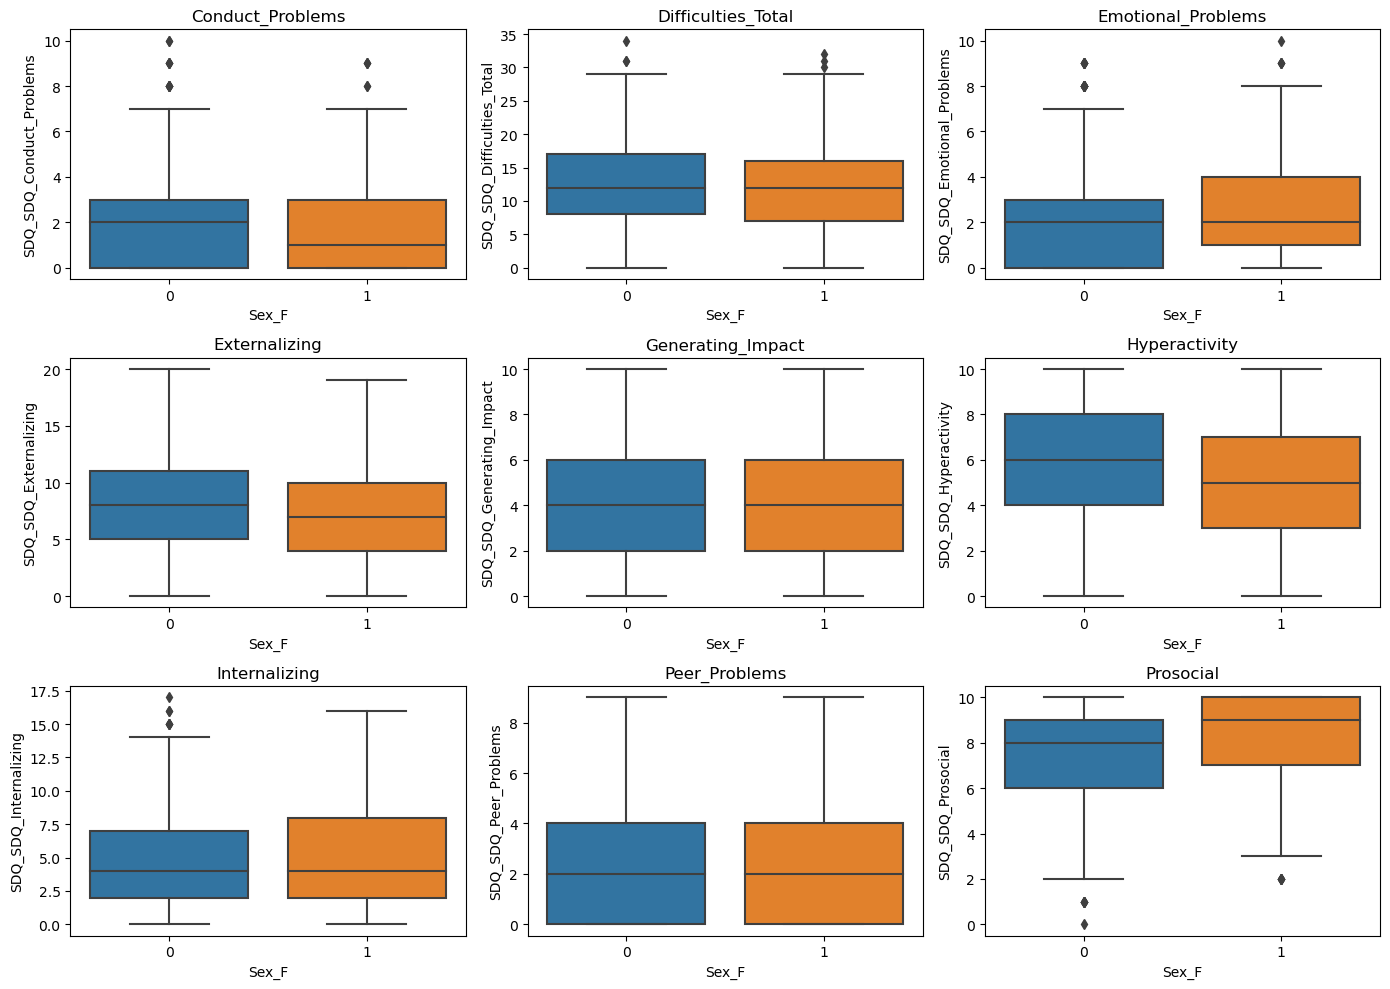

In [14]:
# Box plots by Sex
plt.figure(figsize=(14, 10))
for i, var in enumerate(sdq_vars):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Sex_F', y=var, data=quant_y_df)
    plt.title(var.split('SDQ_SDQ_')[1])
plt.tight_layout()
plt.show()

In [15]:
def plot_catplot(predictor, kind) :
    sns.set(style="ticks")
    g1 = sns.catplot(y=predictor, x="ADHD_Outcome", hue="Sex_F", data=quant_y_df, kind=kind) #, size=5, aspect=.8)
    sns.move_legend(g1, "center left", bbox_to_anchor=(1, 0.5))
    g1.despine(left=True)
    plt.tight_layout()
    plt.show()

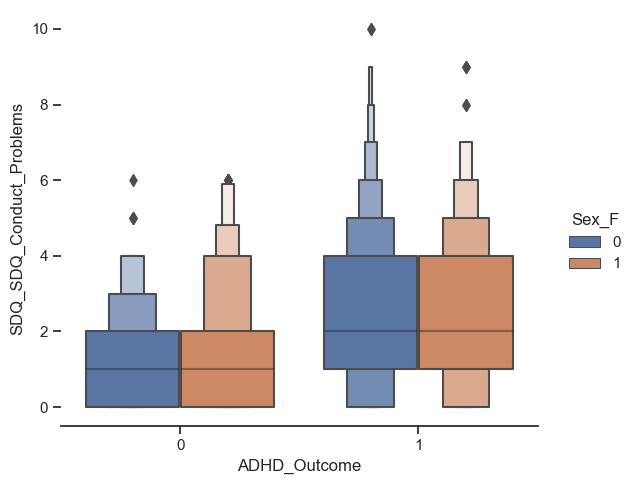

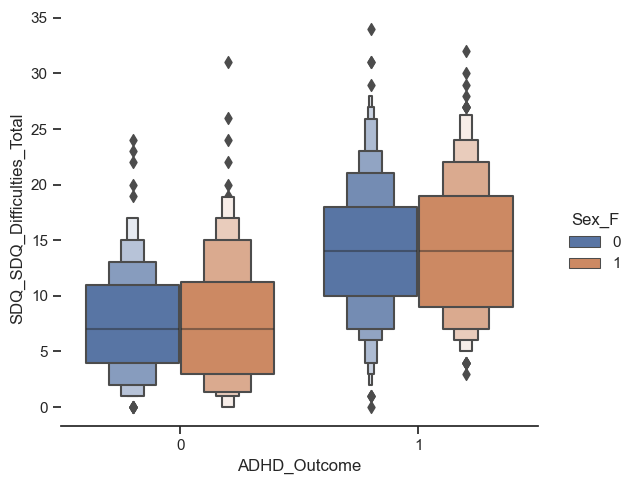

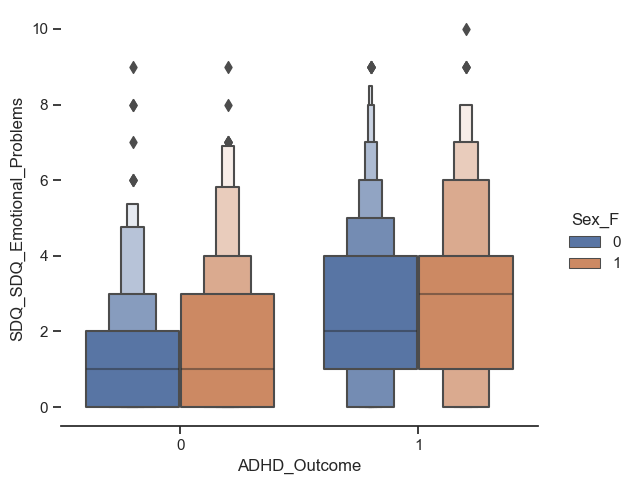

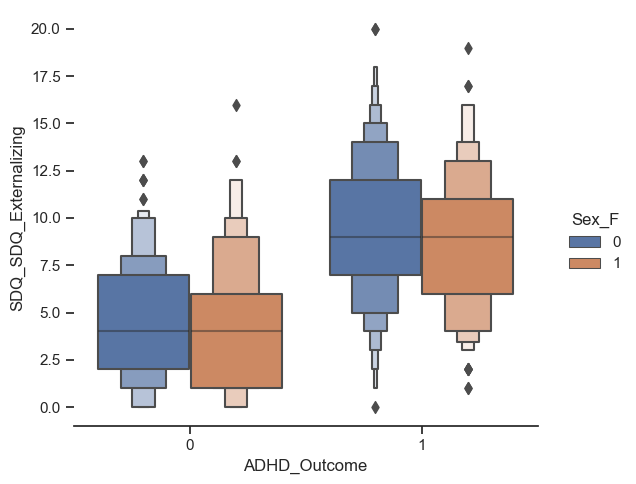

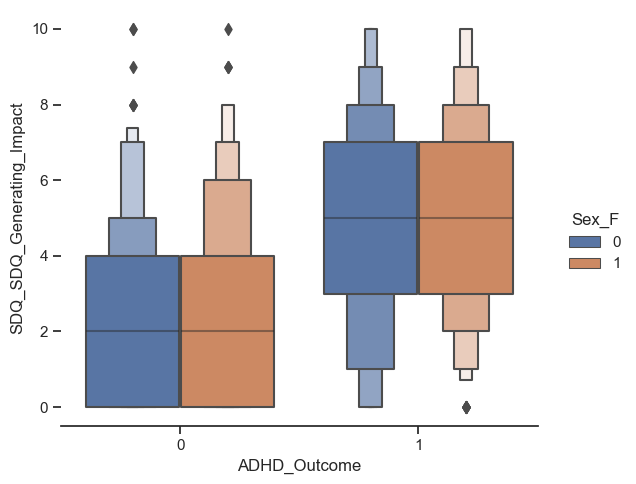

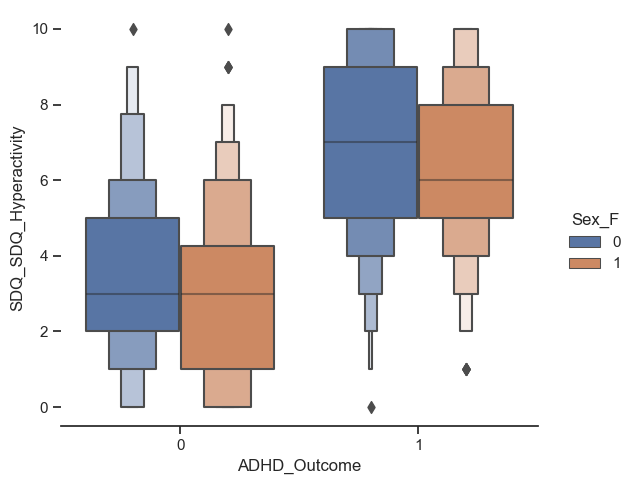

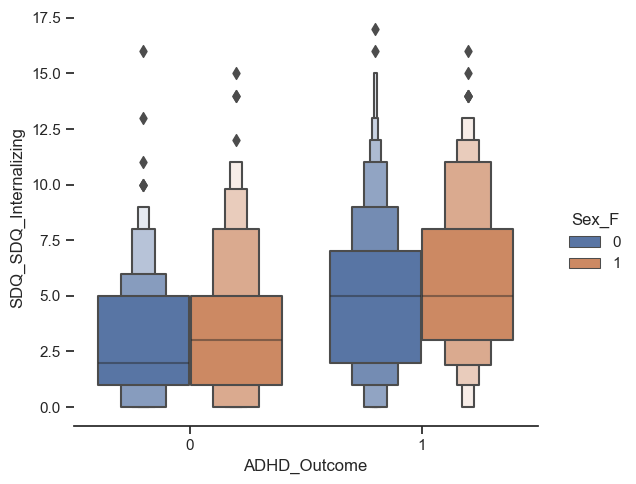

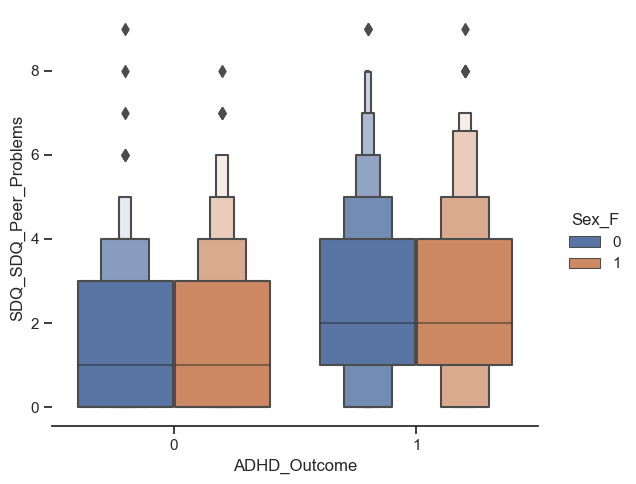

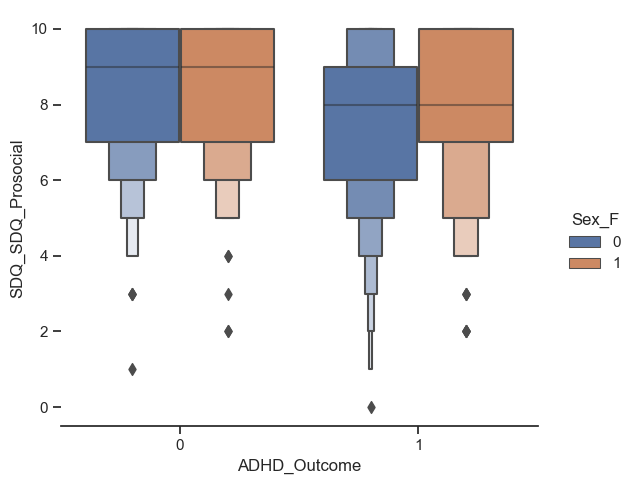

In [16]:
for i in sdq_vars :
    plot_catplot(i, "boxen") #SDQ scores seem to be different between groups

#### Visualization 2 : Parenting Questionnaire

In [17]:
# APQ Features EDA
apq_vars = [col for col in quant_data.columns if 'APQ_P_APQ_P' in col]

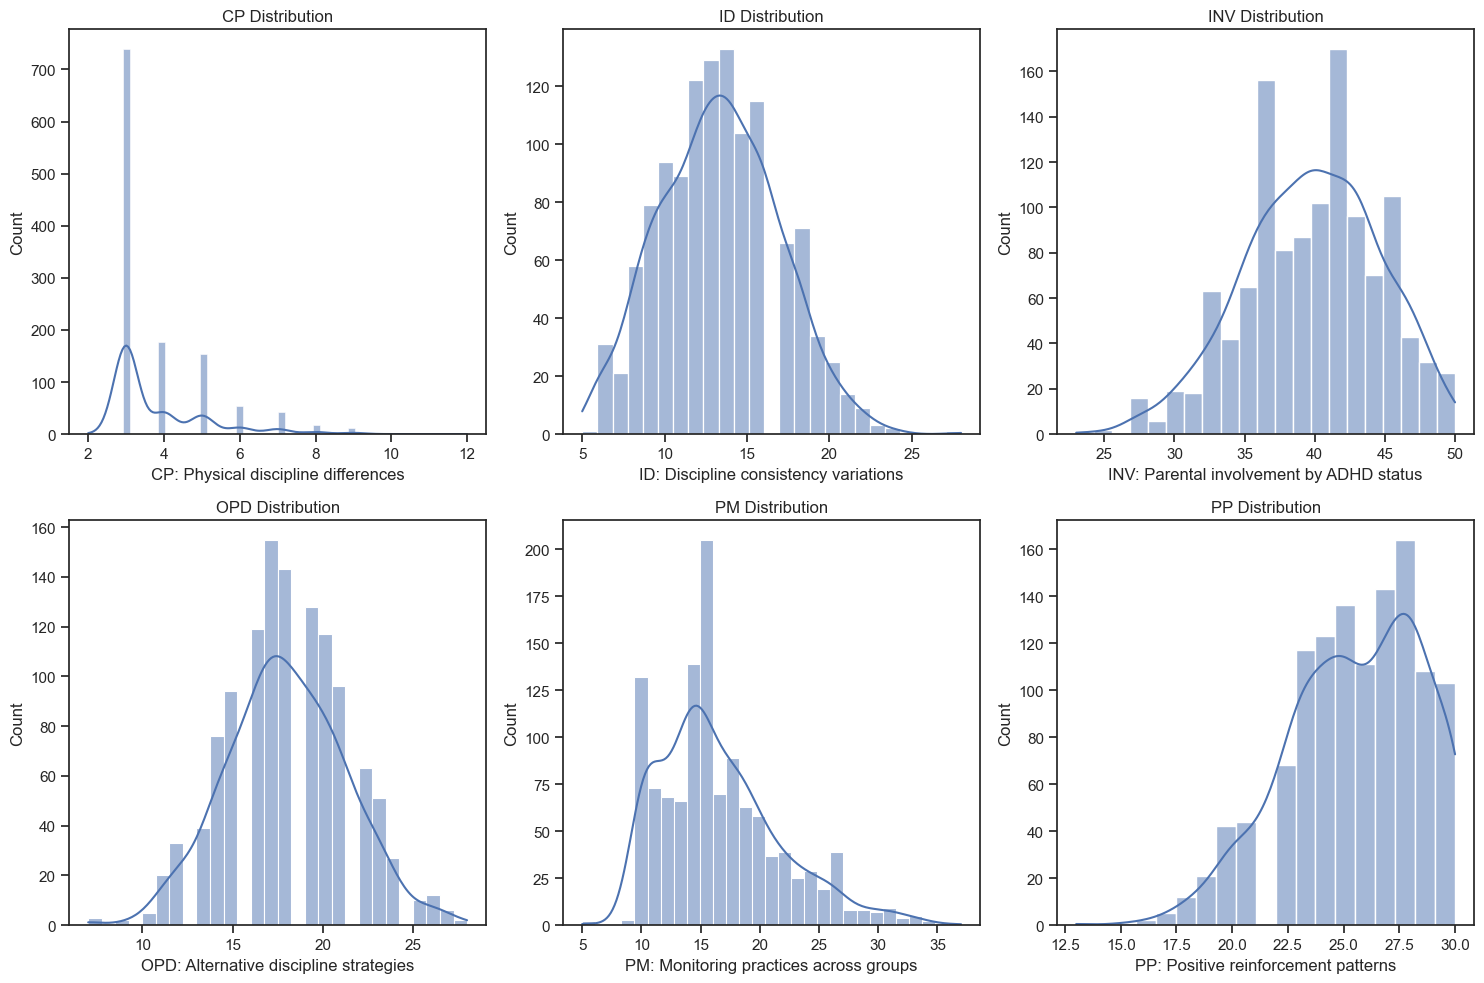

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, var in enumerate(apq_vars):
    sns.histplot(quant_data[var], kde=True, ax=axes[i])
    var_name = var.replace('APQ_P_APQ_P_', '')
    axes[i].set_title(f'{var_name} Distribution')
    
# Add descriptive labels for distribution charts
labels = [
    "CP: Physical discipline differences",
    "ID: Discipline consistency variations",
    "INV: Parental involvement by ADHD status",
    "OPD: Alternative discipline strategies",
    "PM: Monitoring practices across groups",
    "PP: Positive reinforcement patterns"
]

for i, label in enumerate(labels):
    axes[i].set_xlabel(label, wrap=True)
    
plt.tight_layout()
plt.show()

**Insights** 
- Most parents report minimal use of physical discipline
- Normal distribution of discipline inconsistency
- High levels of parental engagement reported
- Balanced distribution of alternative discipline strategies
- Bimodal distribution suggesting two distinct supervision groups
- Strong right-skew: frequent positive reinforcement

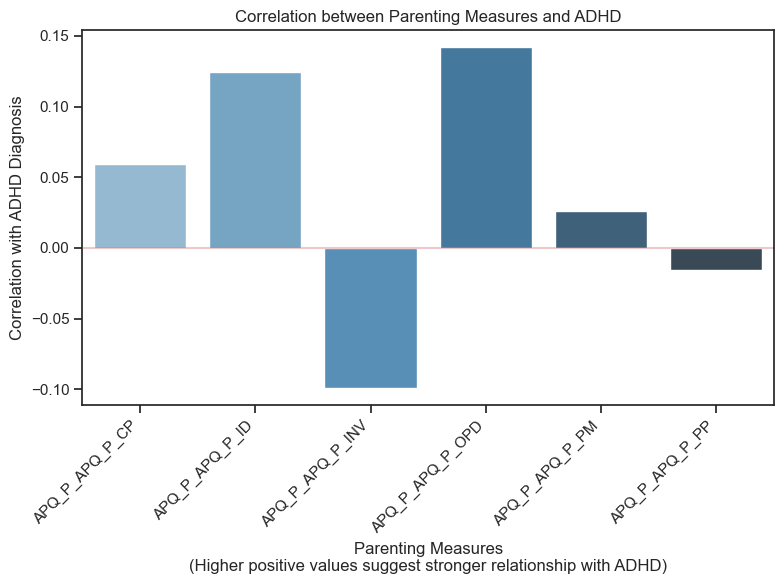

In [19]:
# Correlation between parenting measures and ADHD
corr_apq_adhd = quant_y_df[apq_vars + ['ADHD_Outcome']].corr()['ADHD_Outcome'].drop('ADHD_Outcome')
df_corr = pd.DataFrame(list(corr_apq_adhd.items()), columns=['Feature', 'Correlation'])

plt.figure(figsize=(8, 6))
sns.barplot(data=df_corr, x='Feature', y='Correlation', palette='Blues_d')

plt.title('Correlation between Parenting Measures and ADHD')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Correlation with ADHD Diagnosis')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.xlabel('Parenting Measures\n(Higher positive values suggest stronger relationship with ADHD)', wrap=True)
plt.tight_layout()
plt.show()

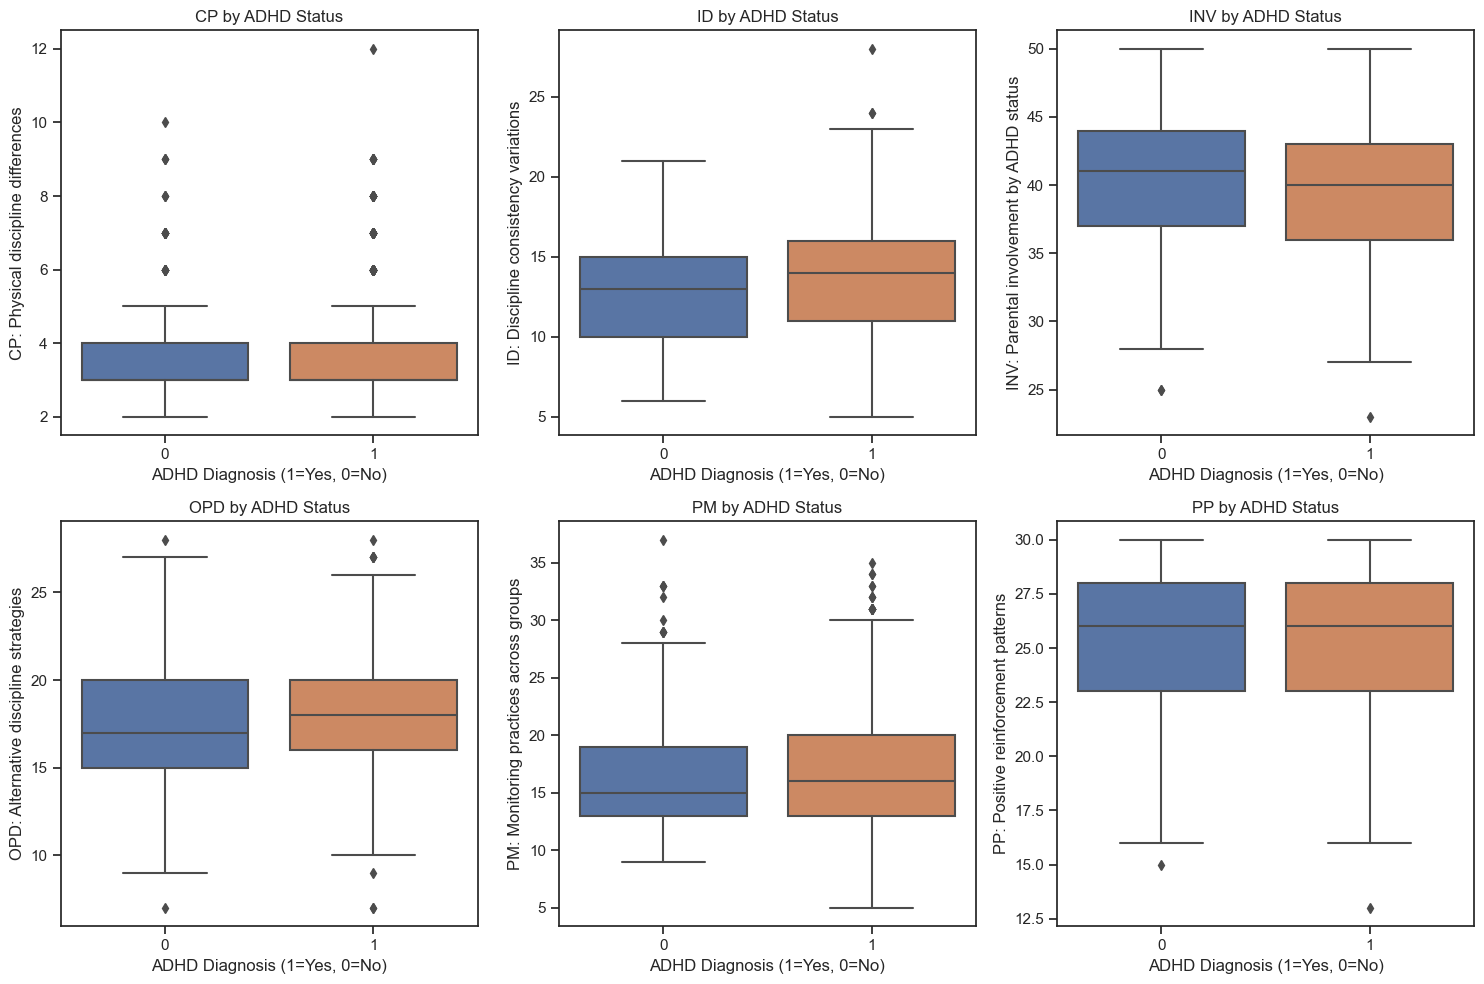

In [20]:
# Compare distributions by ADHD diagnosis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, var in enumerate(apq_vars):
    sns.boxplot(x='ADHD_Outcome', y=var, data=quant_y_df, ax=axes[i])
    var_name = var.replace('APQ_P_APQ_P_', '')
    axes[i].set_title(f'{var_name} by ADHD Status')
    axes[i].set_xlabel('ADHD Diagnosis (1=Yes, 0=No)')
    
for i, label in enumerate(labels):
    axes[i].set_ylabel(label, rotation=90)
    
plt.tight_layout()
plt.show()

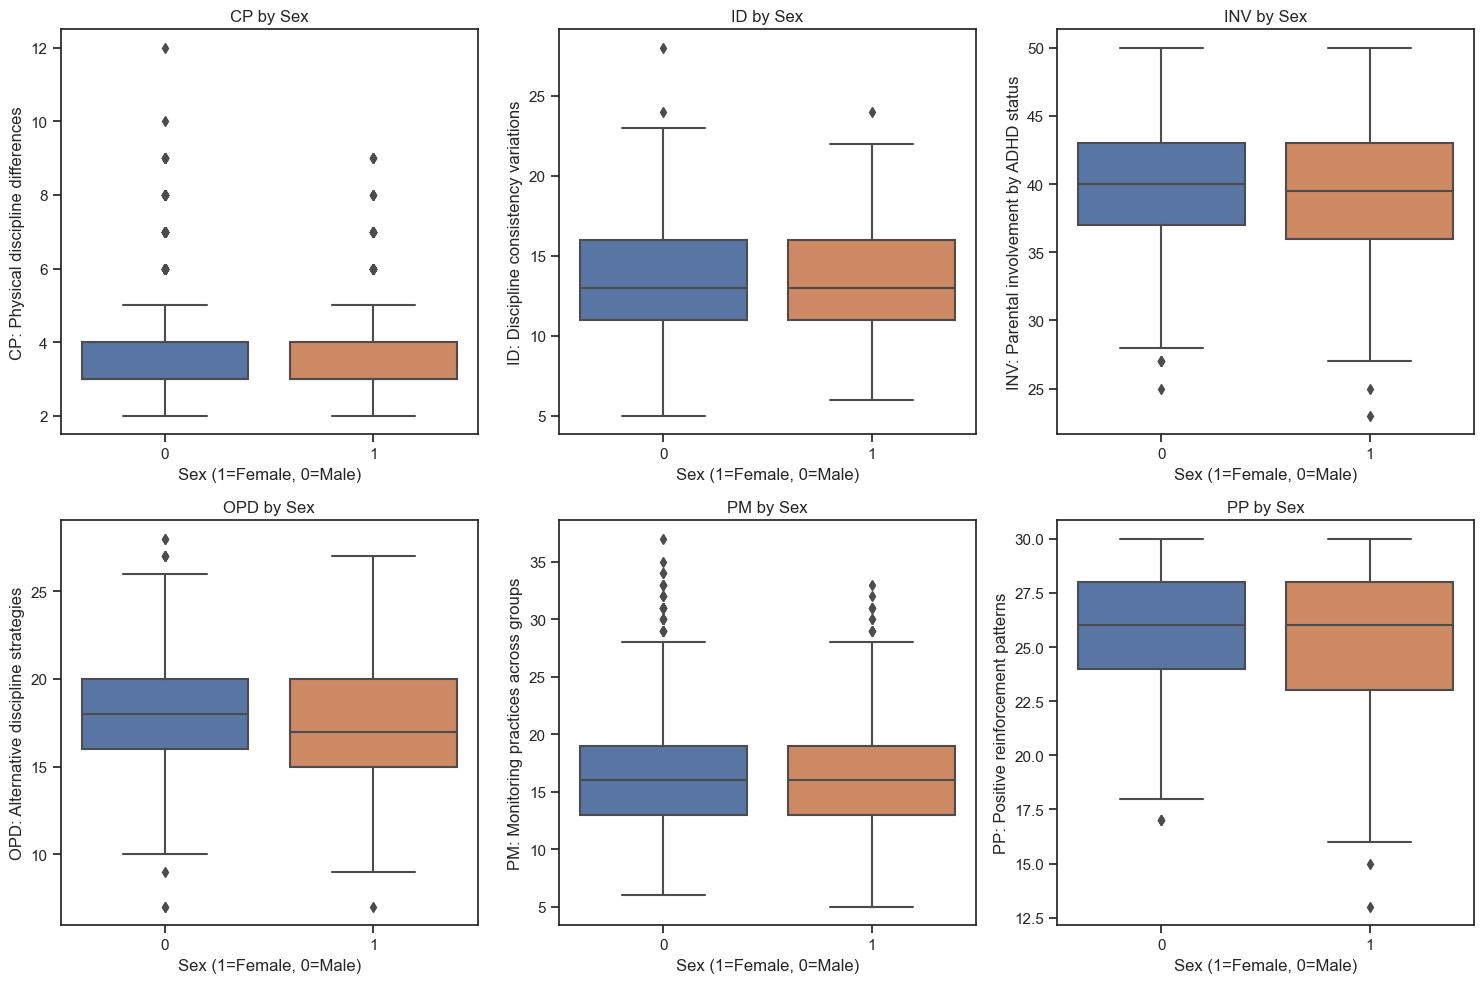

In [21]:
# Relationship between parenting styles and sex
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, var in enumerate(apq_vars):
    sns.boxplot(x='Sex_F', y=var, data=quant_y_df, ax=axes[i])
    var_name = var.replace('APQ_P_APQ_P_', '')
    axes[i].set_title(f'{var_name} by Sex')
    axes[i].set_xlabel('Sex (1=Female, 0=Male)')

for i, label in enumerate(labels):
    axes[i].set_ylabel(label, rotation=90)
    
plt.tight_layout()
plt.show()

- **Corporal Punishment (CP)**: Most parents report minimal use of physical discipline, with scores heavily concentrated at the low end.

- **Inconsistent Discipline (ID)**: Parents show a normal distribution of inconsistency in rule enforcement, with most showing moderate levels.

- **Involvement (INV)**: Parents typically report high levels of engagement with their children, with most scores in the upper range.

- **Other Discipline Practices (OPD)**: Alternative discipline strategies show a balanced distribution with most parents using a moderate amount.

- **Poor Monitoring (PM)**: The bimodal distribution suggests two distinct groups of parents regarding supervision practices.

- **Positive Parenting (PP)**: The strong right-skew indicates that most parents report frequent use of praise and positive reinforcement.

#### Visualization 3 : Clinical Measures

In [22]:
clinical_vars = ['EHQ_EHQ_Total', 'ColorVision_CV_Score']

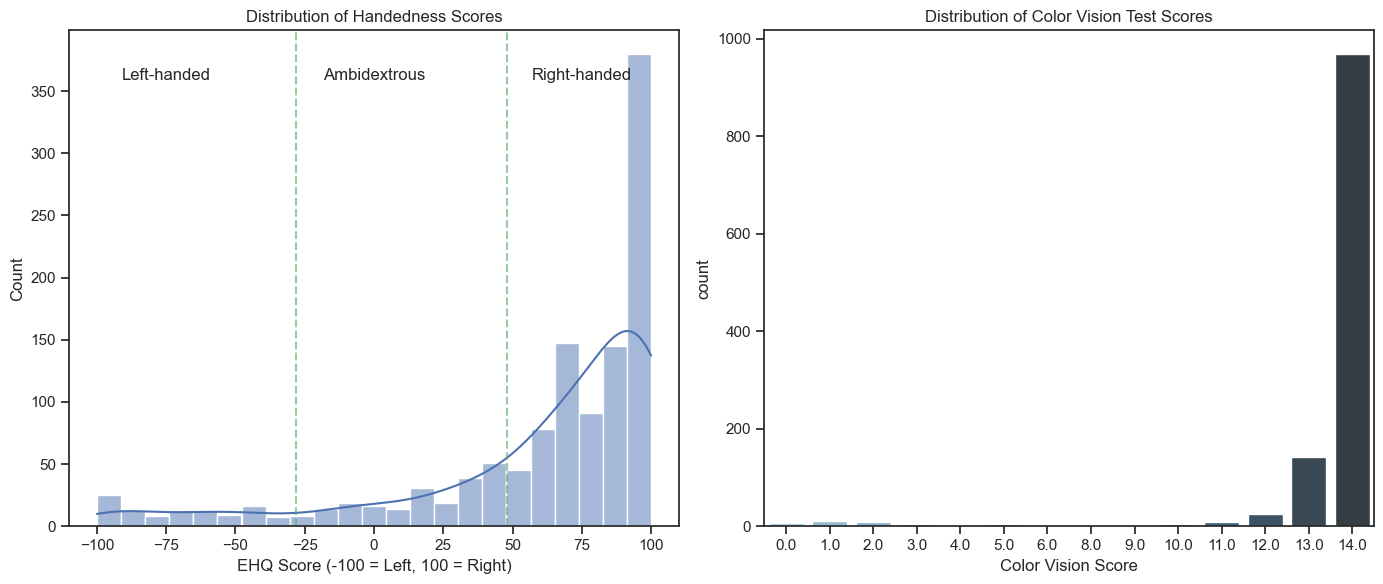

In [23]:
# Distribution of clinical measures
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Handedness distribution
sns.histplot(quant_data['EHQ_EHQ_Total'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Handedness Scores')
axes[0].set_xlabel('EHQ Score (-100 = Left, 100 = Right)')

# Add vertical lines for handedness categories
axes[0].axvline(x=-28, color='g', linestyle='--', alpha=0.6) 
axes[0].axvline(x=48, color='g', linestyle='--', alpha=0.6)
# Add text for handedness regions
axes[0].text(-75, axes[0].get_ylim()[1]*0.9, 'Left-handed', ha='center')
axes[0].text(0, axes[0].get_ylim()[1]*0.9, 'Ambidextrous', ha='center')
axes[0].text(75, axes[0].get_ylim()[1]*0.9, 'Right-handed', ha='center')

# Color vision distribution
sns.countplot(x=quant_data['ColorVision_CV_Score'], ax=axes[1], palette='Blues_d')
axes[1].set_title('Distribution of Color Vision Test Scores')
axes[1].set_xlabel('Color Vision Score')

plt.tight_layout()
plt.show()

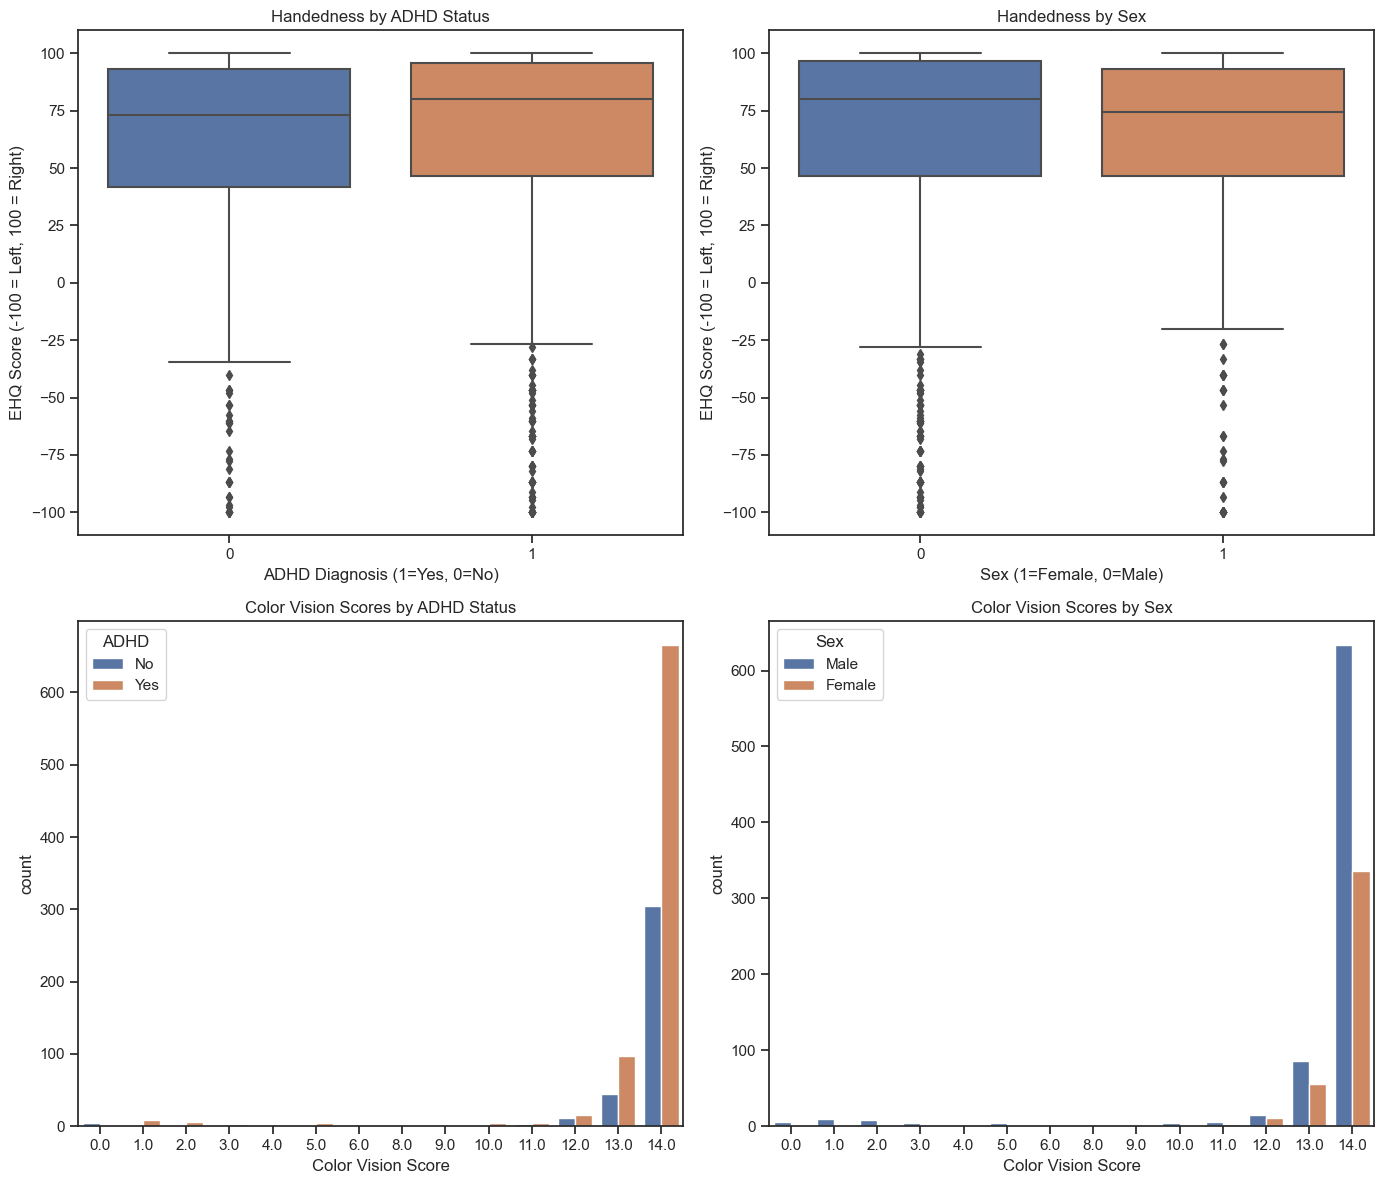

In [24]:
# Relationship with ADHD and Sex
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Handedness by ADHD
sns.boxplot(x='ADHD_Outcome', y='EHQ_EHQ_Total', data=quant_y_df, ax=axes[0, 0])
axes[0, 0].set_title('Handedness by ADHD Status')
axes[0, 0].set_xlabel('ADHD Diagnosis (1=Yes, 0=No)')
axes[0, 0].set_ylabel('EHQ Score (-100 = Left, 100 = Right)')

# Handedness by Sex
sns.boxplot(x='Sex_F', y='EHQ_EHQ_Total', data=quant_y_df, ax=axes[0, 1])
axes[0, 1].set_title('Handedness by Sex')
axes[0, 1].set_xlabel('Sex (1=Female, 0=Male)')
axes[0, 1].set_ylabel('EHQ Score (-100 = Left, 100 = Right)')

# Color vision by ADHD
sns.countplot(x='ColorVision_CV_Score', hue='ADHD_Outcome', data=quant_y_df, ax=axes[1, 0])
axes[1, 0].set_title('Color Vision Scores by ADHD Status')
axes[1, 0].set_xlabel('Color Vision Score')
axes[1, 0].legend(title='ADHD', labels=['No', 'Yes'])

# Color vision by Sex
sns.countplot(x='ColorVision_CV_Score', hue='Sex_F', data=quant_y_df, ax=axes[1, 1])
axes[1, 1].set_title('Color Vision Scores by Sex')
axes[1, 1].set_xlabel('Color Vision Score')
axes[1, 1].legend(title='Sex', labels=['Male', 'Female'])

plt.tight_layout()
plt.show()

In [25]:
# Statistical tests for differences
print("Statistical Tests for Clinical Measures:")

# Handedness by ADHD
from scipy.stats import ttest_ind
adhd_positive = quant_y_df.loc[quant_y_df['ADHD_Outcome'] == 1, 'EHQ_EHQ_Total']
adhd_negative = quant_y_df.loc[quant_y_df['ADHD_Outcome'] == 0, 'EHQ_EHQ_Total']
t_stat, p_val = ttest_ind(adhd_positive, adhd_negative)
print(f"Handedness difference by ADHD: t-stat={t_stat:.3f}, p-value={p_val:.3f}")

# Handedness by Sex
male = quant_y_df.loc[quant_y_df['Sex_F'] == 0, 'EHQ_EHQ_Total']
female = quant_y_df.loc[quant_y_df['Sex_F'] == 1, 'EHQ_EHQ_Total']
t_stat, p_val = ttest_ind(male, female)
print(f"Handedness difference by Sex: t-stat={t_stat:.3f}, p-value={p_val:.3f}")

# Color vision by ADHD
from scipy.stats import chi2_contingency
color_adhd_contingency = pd.crosstab(quant_y_df['ColorVision_CV_Score'], quant_y_df['ADHD_Outcome'])
chi2, p_val, dof, expected = chi2_contingency(color_adhd_contingency)
print(f"Color vision association with ADHD: chi2={chi2:.3f}, p-value={p_val:.3f}")

# Color vision by Sex
color_sex_contingency = pd.crosstab(quant_y_df['ColorVision_CV_Score'], quant_y_df['Sex_F'])
chi2, p_val, dof, expected = chi2_contingency(color_sex_contingency)
print(f"Color vision association with Sex: chi2={chi2:.3f}, p-value={p_val:.3f}")

Statistical Tests for Clinical Measures:
Handedness difference by ADHD: t-stat=nan, p-value=nan
Handedness difference by Sex: t-stat=nan, p-value=nan
Color vision association with ADHD: chi2=12.299, p-value=0.503
Color vision association with Sex: chi2=20.216, p-value=0.090


### Categorical Metadata

#### Demographic Features

| Feature | Format | Range | Example | Description |
|:--------|:-------|:------|:--------|:------------|
| **Basic_Demos_Enroll_Year** | Integer | (Study years) | 2019 | Year participant joined the study. |
| **Basic_Demos_Study_Site** | Categorical integer | Site-specific codes | 2 | Location code where the participant was tested. |
| **PreInt_Demos_Fam_Child_Ethnicity** | Categorical integer | Ethnicity codes | 0 | The child's ethnic background (e.g., 0 = Not Hispanic or Latino). |
| **PreInt_Demos_Fam_Child_Race** | Categorical integer | Race codes | 1 | The child's racial background (e.g., 1 = White). |
| **Barratt_Barratt_P1_Edu** | Categorical integer | Education codes | 5 | Parent's education level (e.g., 5 = Bachelor's degree). |


**_Note that:_** The variation in sample sizes across sites may impact:
- Statistical power
- Generalizability of research findings
- Potential site-specific biases

In [26]:
cat_data.head(10)

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN
5,0cduHhwrQN4r,2017,1,0.0,0.0,2.0,18.0,25.0,15.0,40.0
6,0FUWCjn9YMN1,2017,1,0.0,1.0,2.0,15.0,0.0,15.0,30.0
7,0Hthz5IFXhpw,2016,2,0.0,1.0,1.0,12.0,35.0,18.0,40.0
8,0hzWGU6XYSVp,2019,3,0.0,0.0,3.0,21.0,45.0,21.0,45.0
9,0i2Tz2XUL4vm,2019,1,0.0,0.0,2.0,15.0,NaN,9.0,NaN


In [27]:
cat_data.info() #missing data 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1170 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1159 non-null   float64
 5   MRI_Track_Scan_Location           1210 non-null   float64
 6   Barratt_Barratt_P1_Edu            1198 non-null   float64
 7   Barratt_Barratt_P1_Occ            1182 non-null   float64
 8   Barratt_Barratt_P2_Edu            1015 non-null   float64
 9   Barratt_Barratt_P2_Occ            991 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 94.9+ KB


#### Visualization 4: Demographic Measures 

In [28]:
cat_variables = cat_data.columns[cat_data.columns!='participant_id']

In [29]:
ethnicity_labels = {
    0: 'Not Hispanic/Latino', 
    1: 'Hispanic/Latino', 
    2: 'Decline to Specify', 
    3: 'Unknown'
}

race_labels_dict = {
    0: 'White/Caucasian', 
    1: 'Black/African American', 
    2: 'Hispanic', 
    3: 'Asian', 
    4: 'Indian', 
    5: 'Native American Indian', 
    6: 'American Indian/Alaskan Native', 
    7: 'Native Hawaiian/Pacific Islander', 
    8: 'Two or More Races', 
    9: 'Other Race', 
    10: 'Unknown', 
    11: 'Choose Not to Specify'
}

edu_labels_dict = {
    3: 'Less than 7th grade',
    6: 'Junior High',
    9: 'Partial High School',
    12: 'High School Graduate',
    15: 'Partial College',
    18: 'College Education',
    21: 'Graduate Degree'
}

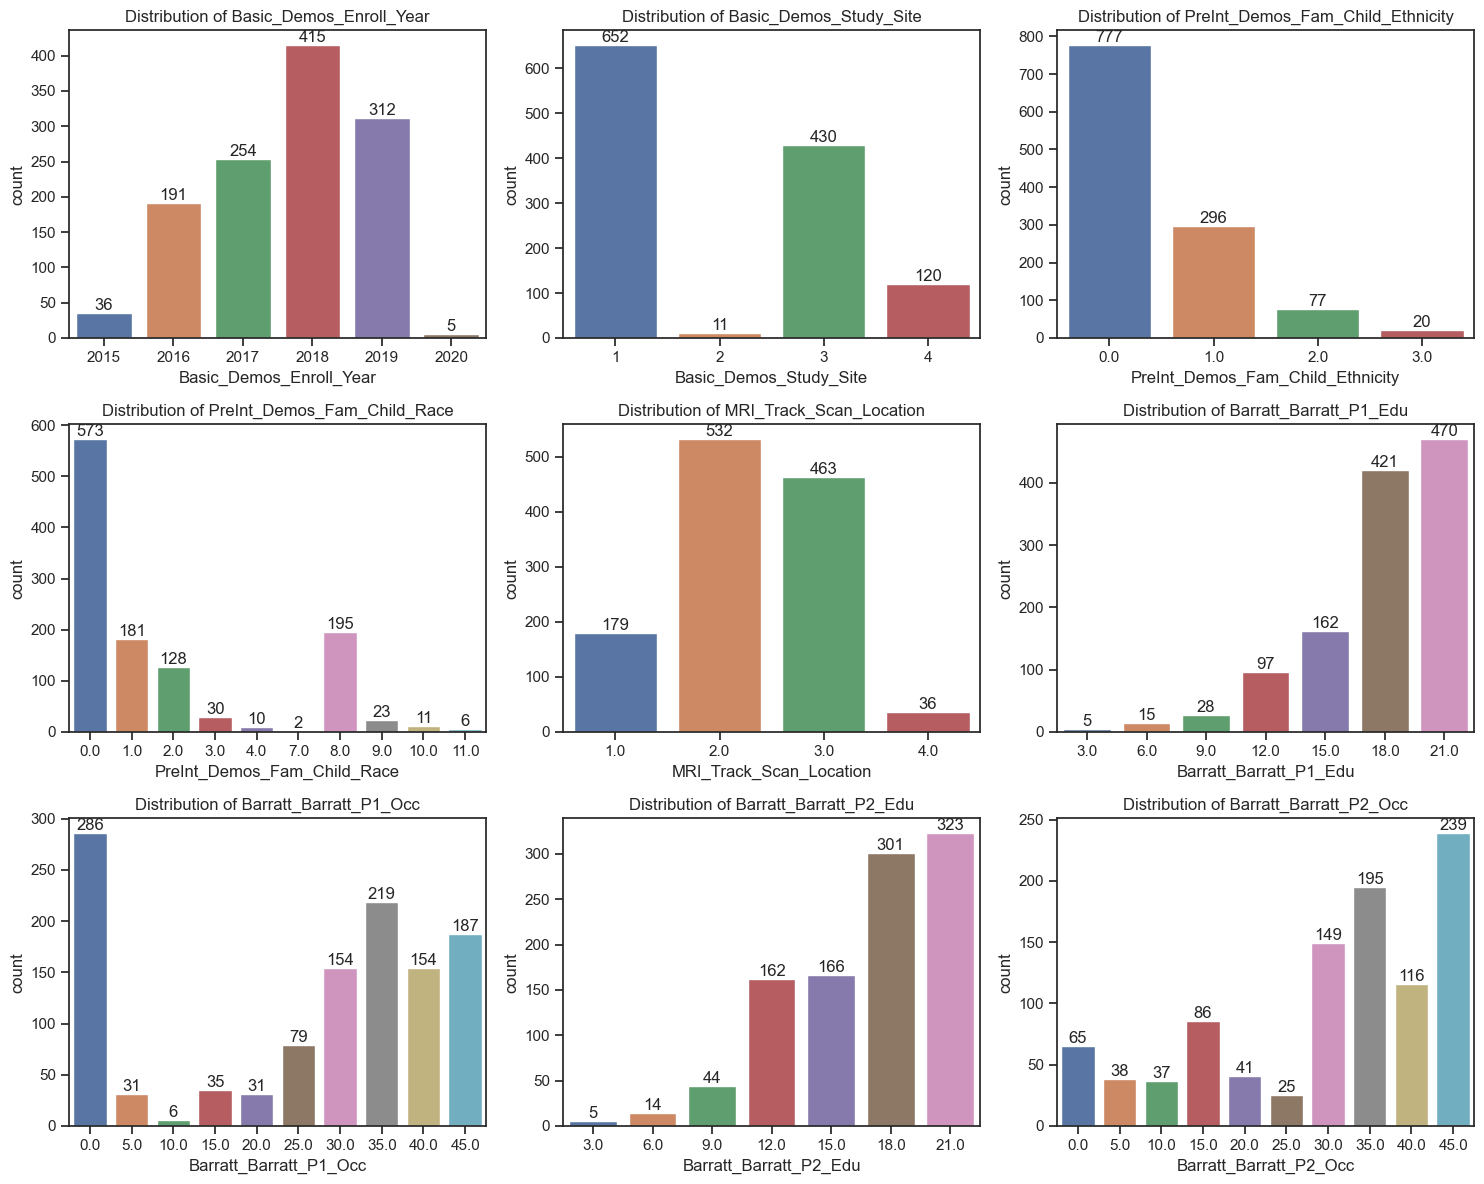

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, var in enumerate(cat_variables):
    ax = sns.countplot(x=var, data=cat_data[[var]], ax=axes[i])
    for p in ax.patches:
        count = int(p.get_height())
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(f'{count}', (x, y), ha='center', va='bottom')
    axes[i].set_title(f'Distribution of {var}')
    
plt.tight_layout()
plt.show()

### fMRI Metadata

#### Brain Connectivity Data (Connectome Features)

| Feature | Format | Range | Example | Description |
|:--------|:-------|:------|:--------|:------------|
| **0throw_1stcolumn** | Float | -1 to +1 | 0.327 | Correlation between brain regions 0 and 1. A value of 0.327 indicates moderate positive correlation. |
| **5throw_8thcolumn** | Float | -1 to +1 | -0.156 | Correlation between brain regions 5 and 8. A value of -0.156 indicates weak negative correlation. |
| **12throw_19thcolumn** | Float | -1 to +1 | 0.082 | Correlation between brain regions 12 and 19. A value of 0.082 indicates very weak positive correlation. |
| **64throw_80thcolumn** | Float | -1 to +1 | 0.511 | Correlation between brain regions 64 and 80. A value of 0.511 indicates strong positive correlation. |
| **98throw_112thcolumn** | Float | -1 to +1 | -0.372 | Correlation between brain regions 98 and 112. A value of -0.372 indicates moderate negative correlation. |

#### Connectome Interpretation Examples:
- Strong positive correlation (0.7) between frontal and parietal regions might indicate good executive function
- Negative correlation (-0.4) between amygdala and prefrontal regions could indicate emotional regulation difficulties

In [31]:
mri_data.head(10)

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.222930,0.527903,0.429966,0.060457,0.566489,0.315342,0.508408,-0.078290,0.525692,...,0.224985,0.397448,0.422966,0.184642,0.305549,0.420349,0.016328,0.561864,0.471170,0.365221
1,WHWymJu6zNZi,0.614765,0.577255,0.496127,0.496606,0.404686,0.439724,0.122590,-0.085452,0.120673,...,0.217546,-0.014549,0.000440,-0.096451,0.454501,0.343916,0.167313,0.607656,0.550623,0.503176
2,4PAQp1M6EyAo,-0.116833,0.458408,0.260703,0.639031,0.769337,0.442528,0.637110,0.192010,0.520379,...,0.342487,-0.021141,-0.037836,0.075069,0.412712,0.292708,0.391005,0.461544,0.508912,0.624232
3,obEacy4Of68I,0.199688,0.752714,0.658283,0.575096,0.692867,0.645789,0.522750,0.412188,0.530843,...,0.103562,-0.178313,0.210983,-0.018666,0.436313,0.592982,0.216205,0.341272,0.440313,0.558193
4,s7WzzDcmDOhF,0.227321,0.613268,0.621447,0.562673,0.736709,0.589813,0.266676,0.359668,0.300771,...,-0.164956,0.007064,-0.120904,-0.488095,0.493575,-0.215361,0.210685,0.055850,0.119065,0.108273
5,s55ZRHrJtnlL,0.337316,0.823123,0.733585,0.418883,0.771445,0.653699,0.693189,0.345408,0.729822,...,0.119869,0.047217,0.139147,0.187316,0.534683,0.175817,0.291163,0.569374,0.737414,0.716293
6,sId1cQF5F22m,0.205613,0.514554,0.580002,0.356749,0.355509,0.402521,0.503667,-0.090709,0.442115,...,-0.068885,-0.288361,-0.259806,-0.072032,0.395912,0.340496,0.217748,0.408298,0.174187,0.659205
7,T4CaImRntWnB,-0.190693,0.311654,0.309758,0.466017,0.461799,0.348240,0.258351,0.267011,0.204740,...,0.011235,0.172349,0.099238,0.324650,0.266663,0.262601,0.096195,0.497883,0.617897,0.555232
8,a5JFxSZjVg5i,0.243401,0.274912,0.364787,0.252179,0.645695,0.677565,0.480189,0.400882,0.407494,...,-0.057347,-0.161009,-0.156577,-0.081074,0.767887,0.607772,0.241883,0.708180,0.247329,0.452594
9,VZnIq2hRErI5,0.182886,0.734523,0.286137,0.300662,0.542568,0.707586,0.646182,0.263905,0.554053,...,0.032387,0.407388,0.328920,0.364869,0.569350,0.266910,0.458811,0.567601,0.723238,0.547051


In [32]:
mri_data.describe()

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
count,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,...,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000
mean,0.185265,0.583053,0.439351,0.450398,0.584654,0.554164,0.508957,0.282565,0.426095,0.254628,...,0.044413,-0.079307,-0.037423,0.009393,0.557159,0.376624,0.370711,0.500415,0.476418,0.543181
std,0.238481,0.172632,0.235019,0.212111,0.195918,0.157533,0.179127,0.189683,0.202979,0.208395,...,0.191253,0.204061,0.205052,0.198820,0.150605,0.197995,0.191249,0.177047,0.177732,0.170237
min,-0.657053,-0.224815,-0.517318,-0.440235,-0.486239,-0.059139,-0.181009,-0.341516,-0.353362,-0.578757,...,-0.547155,-0.620350,-0.584162,-0.605647,-0.052284,-0.359869,-0.553067,-0.302408,-0.307228,-0.224057
25%,0.028235,0.495514,0.286137,0.314428,0.486735,0.462448,0.406548,0.152607,0.319183,0.124448,...,-0.087566,-0.220508,-0.187871,-0.124404,0.469147,0.262601,0.242569,0.389078,0.367971,0.442283
50%,0.192886,0.606585,0.469826,0.479330,0.623346,0.577187,0.534237,0.290552,0.452538,0.268802,...,0.043204,-0.093695,-0.044155,0.004375,0.573840,0.391739,0.388528,0.524508,0.496103,0.566455
75%,0.358902,0.710758,0.626871,0.604438,0.726116,0.670072,0.636448,0.423821,0.570470,0.402742,...,0.177608,0.049707,0.104526,0.146865,0.666128,0.521904,0.505970,0.630443,0.600065,0.667402
max,0.824448,0.907209,0.884576,0.876987,0.893974,0.882400,0.892983,0.803253,0.854104,0.828335,...,0.670512,0.596618,0.630932,0.666169,0.889148,0.866371,0.828784,0.914021,0.898459,0.903364


In [33]:
mri_data.isnull().sum().sum()

0

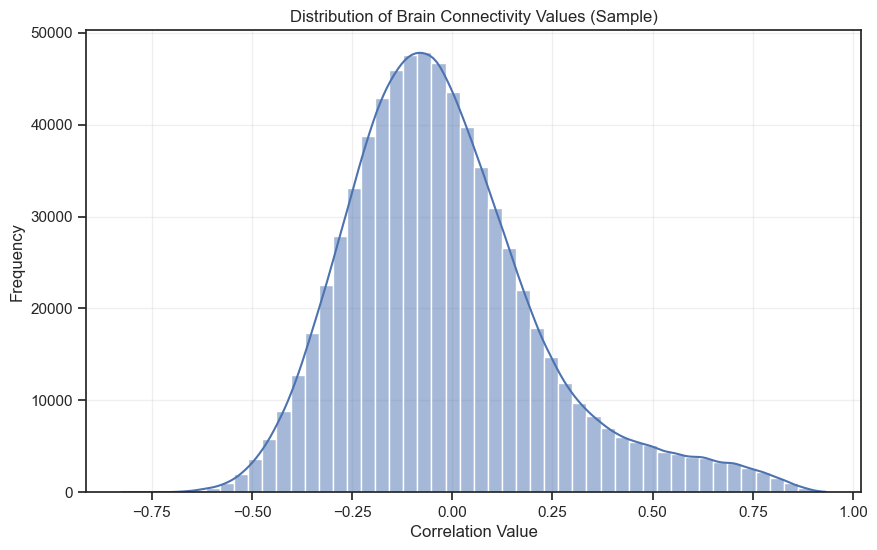

In [34]:
# Distribution of connectivity values (sample)
connectome_cols = [col for col in mri_data.columns if (col.startswith('0throw') or 
                                                    col.startswith('1throw') or 
                                                    col.startswith('2throw'))]
plt.figure(figsize=(10, 6))
# Take a random sample to avoid memory issues
sample_size = min(1000, len(connectome_cols))
np.random.seed(42)
sample_cols = np.random.choice(connectome_cols, sample_size)
all_values = mri_data[sample_cols].values.flatten()
all_values = all_values[~np.isnan(all_values)]  # Remove NaN values if any

sns.histplot(all_values, kde=True, bins=50)
plt.title('Distribution of Brain Connectivity Values (Sample)')
plt.xlabel('Correlation Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

Most values are centered around zero, with fewer strong positive or negative correlations.

In [35]:
mri_y_data = pd.merge(mri_data, y_data, on='participant_id')

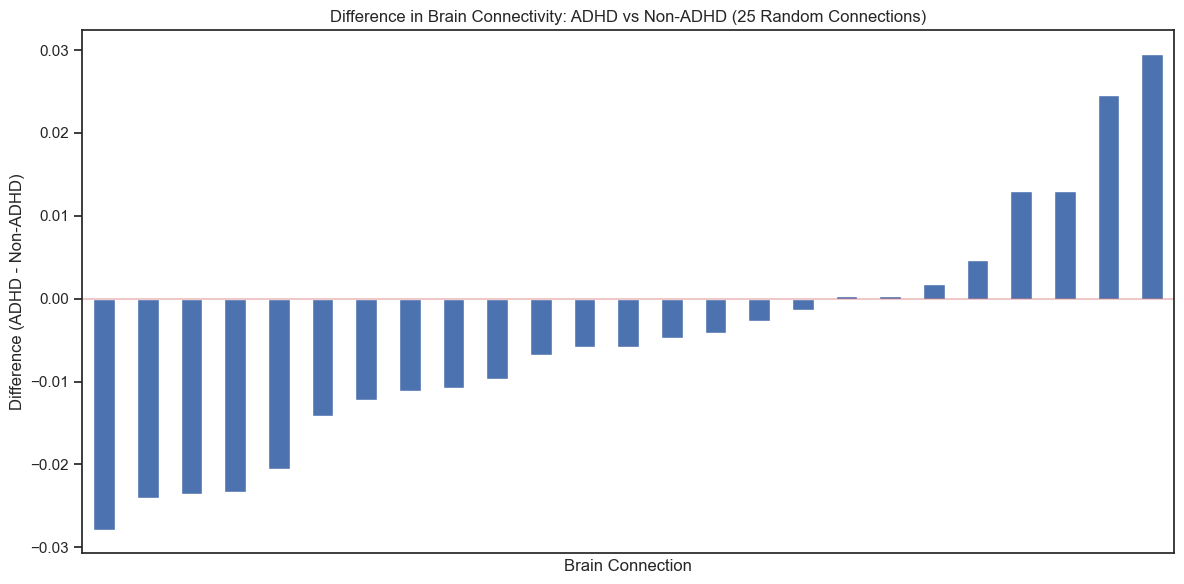

In [36]:
# Simple visualization of connectivity difference between ADHD and non-ADHD
# Take just 25 random features for a simple comparison
sample_size = 25
np.random.seed(0)
tiny_sample = np.random.choice(connectome_cols, sample_size)

# Calculate means by group
adhd_means = mri_y_data[mri_y_data['ADHD_Outcome']==1][tiny_sample].mean()
non_adhd_means = mri_y_data[mri_y_data['ADHD_Outcome']==0][tiny_sample].mean()
diff = adhd_means - non_adhd_means

# Plot differences
plt.figure(figsize=(12, 6))
diff.sort_values().plot(kind='bar')
plt.title('Difference in Brain Connectivity: ADHD vs Non-ADHD (25 Random Connections)')
plt.xlabel('Brain Connection')
plt.ylabel('Difference (ADHD - Non-ADHD)')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.xticks([])  # Hide feature names to avoid clutter
plt.tight_layout()
plt.show()

In [37]:
# Take just 10 random features for a simple comparison
sample_size = 10
np.random.seed(42)
tiny_sample = np.random.choice(connectome_cols, sample_size)

# Calculate means by group
adhd_means = mri_y_data[mri_y_data['ADHD_Outcome']==1][tiny_sample].mean()
non_adhd_means = mri_y_data[mri_y_data['ADHD_Outcome']==0][tiny_sample].mean()
diff = adhd_means - non_adhd_means

# Create a comparative table
comparison = pd.DataFrame({
    'ADHD': adhd_means,
    'Non-ADHD': non_adhd_means,
    'Difference': diff
})
print(comparison.round(4))

                      ADHD  Non-ADHD  Difference
0throw_103thcolumn  0.2232    0.1748      0.0483
2throw_41thcolumn  -0.0681   -0.0584     -0.0097
1throw_73thcolumn   0.0114    0.0060      0.0054
0throw_107thcolumn  0.3131    0.3467     -0.0336
0throw_72thcolumn  -0.0108   -0.0169      0.0062
0throw_21thcolumn  -0.0614   -0.0419     -0.0195
0throw_122thcolumn -0.0882   -0.0943      0.0061
2throw_72thcolumn   0.0309    0.0370     -0.0061
1throw_17thcolumn  -0.0982   -0.0829     -0.0153
1throw_133thcolumn  0.0061    0.0161     -0.0100


There are differences in brain connectivity between ADHD and non-ADHD groups.
- Positive numbers mean connections stronger in ADHD subjects
- Negative numbers mean connections stronger in non-ADHD subjects

## Data processing 

### Missing data imputation
Since the dataset is small, so imputation method is more suitable.

In [38]:
# Median Imputation
quant_data.fillna({'EHQ_EHQ_Total':quant_data['EHQ_EHQ_Total'].median()}, inplace = True)
quant_data.fillna({'ColorVision_CV_Score':quant_data['ColorVision_CV_Score'].median()}, inplace = True)
quant_data.fillna({'MRI_Track_Age_at_Scan':quant_data['MRI_Track_Age_at_Scan'].median()}, inplace = True)

In [39]:
quant_data[quant_data['SDQ_SDQ_Conduct_Problems'].isnull()]

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
19,16aihxrHTH3I,100.00,14.0,4.0,18.0,38.0,21.0,25.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.537873
52,2Mjpn48uEjoY,33.35,13.0,3.0,18.0,45.0,22.0,15.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.425849
140,7DOnnFs86L8o,100.00,14.0,4.0,9.0,42.0,17.0,14.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.661875
183,A1AXFSUEtLFQ,60.00,13.0,3.0,10.0,40.0,17.0,16.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.173169
703,MMH1uM7wltAr,-46.67,14.0,3.0,13.0,40.0,17.0,15.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.400752
801,p09fwn1IZB6X,66.67,14.0,3.0,10.0,47.0,15.0,14.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.706365
843,qbE8PJ1yZYQB,73.34,14.0,3.0,10.0,43.0,23.0,24.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.739219
978,U3FzDZTOsMlD,81.14,14.0,5.0,15.0,31.0,20.0,21.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.261464
1073,WHWymJu6zNZi,14.47,14.0,7.0,22.0,36.0,23.0,16.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.670088


In [40]:
quant_data[quant_data['APQ_P_APQ_P_CP'].isnull()]

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
120,64kiQGd5o5kP,71.14,14.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,7.0,0.0,5.0,0.0,3.0,2.0,2.0,9.0,6.172826
350,eC2397lXg3Bm,100.00,14.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,11.0,8.0,0.0,0.0,0.0,11.0,3.0,10.0,10.739219
362,emH1j2pf9MZk,77.80,14.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,16.0,3.0,9.0,3.0,5.0,7.0,4.0,9.0,10.739219
368,epGIlkmYMthb,-16.68,13.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,8.0,0.0,3.0,4.0,3.0,5.0,5.0,5.0,6.235911
421,FudKx3F8glFq,8.94,14.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,6.0,0.0,4.0,3.0,1.0,2.0,2.0,7.0,10.739219
479,HAHYSPs753Cc,13.34,14.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,6.0,0.0,5.0,0.0,2.0,1.0,1.0,9.0,10.739219
735,NHpNjWCsdA90,60.00,14.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,6.0,0.0,6.0,3.0,3.0,0.0,0.0,10.0,5.360255
1076,WK20sSlccEMn,33.35,14.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,10.0,12.001368
1084,wRGO69GjV1v6,77.80,14.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,12.0,1.0,9.0,2.0,8.0,3.0,2.0,9.0,6.555783
1098,X7Dq6Oa96HfM,-100.00,14.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,22.0,6.0,13.0,4.0,10.0,9.0,3.0,8.0,9.411362


In [41]:
#Regression imputation
imp = IterativeImputer(random_state=0)
imputed_quant_data = pd.DataFrame(imp.fit_transform(quant_data[quant_variables]), columns=quant_variables)

In [42]:
imputed_quant_data.isnull().sum().sum()

0

In [43]:
#Categorical imputation
imputer = SimpleImputer(strategy='most_frequent')
imputed_cat_data = pd.DataFrame(imputer.fit_transform(cat_data), columns=cat_data.columns)

In [44]:
imputed_cat_data.isnull().sum().sum()

0

### One-hot encoding

In [45]:
cat_data_encode = imputed_cat_data.drop(columns=['MRI_Track_Scan_Location',
                                        'Basic_Demos_Enroll_Year',
                                        'Basic_Demos_Study_Site']) #drop unimportant categorical variables 

In [46]:
cat_variables_drop = cat_data_encode.columns[cat_data_encode.columns!='participant_id']
for col in cat_variables_drop :
    cat_data_encode[col] = cat_data_encode[col].astype('category')

cat_data_encode.dtypes

participant_id                        object
PreInt_Demos_Fam_Child_Ethnicity    category
PreInt_Demos_Fam_Child_Race         category
Barratt_Barratt_P1_Edu              category
Barratt_Barratt_P1_Occ              category
Barratt_Barratt_P2_Edu              category
Barratt_Barratt_P2_Occ              category
dtype: object

In [47]:
cat_encoded = pd.get_dummies(cat_data_encode[cat_variables_drop.tolist()], drop_first=True)
cat_encoded_final = pd.concat([cat_data_encode.drop(columns=cat_variables_drop), cat_encoded], axis=1)

cat_encoded_final.head(10)

,participant_id,PreInt_Demos_Fam_Child_Ethnicity_1.0,PreInt_Demos_Fam_Child_Ethnicity_2.0,PreInt_Demos_Fam_Child_Ethnicity_3.0,PreInt_Demos_Fam_Child_Race_1.0,PreInt_Demos_Fam_Child_Race_2.0,PreInt_Demos_Fam_Child_Race_3.0,PreInt_Demos_Fam_Child_Race_4.0,PreInt_Demos_Fam_Child_Race_7.0,PreInt_Demos_Fam_Child_Race_8.0,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,00aIpNTbG5uh,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,00fV0OyyoLfw,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,04X1eiS79T4B,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,05ocQutkURd6,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,06YUNBA9ZRLq,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
5,0cduHhwrQN4r,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
6,0FUWCjn9YMN1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
7,0Hthz5IFXhpw,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8,0hzWGU6XYSVp,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
9,0i2Tz2XUL4vm,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


### Data Scaling 

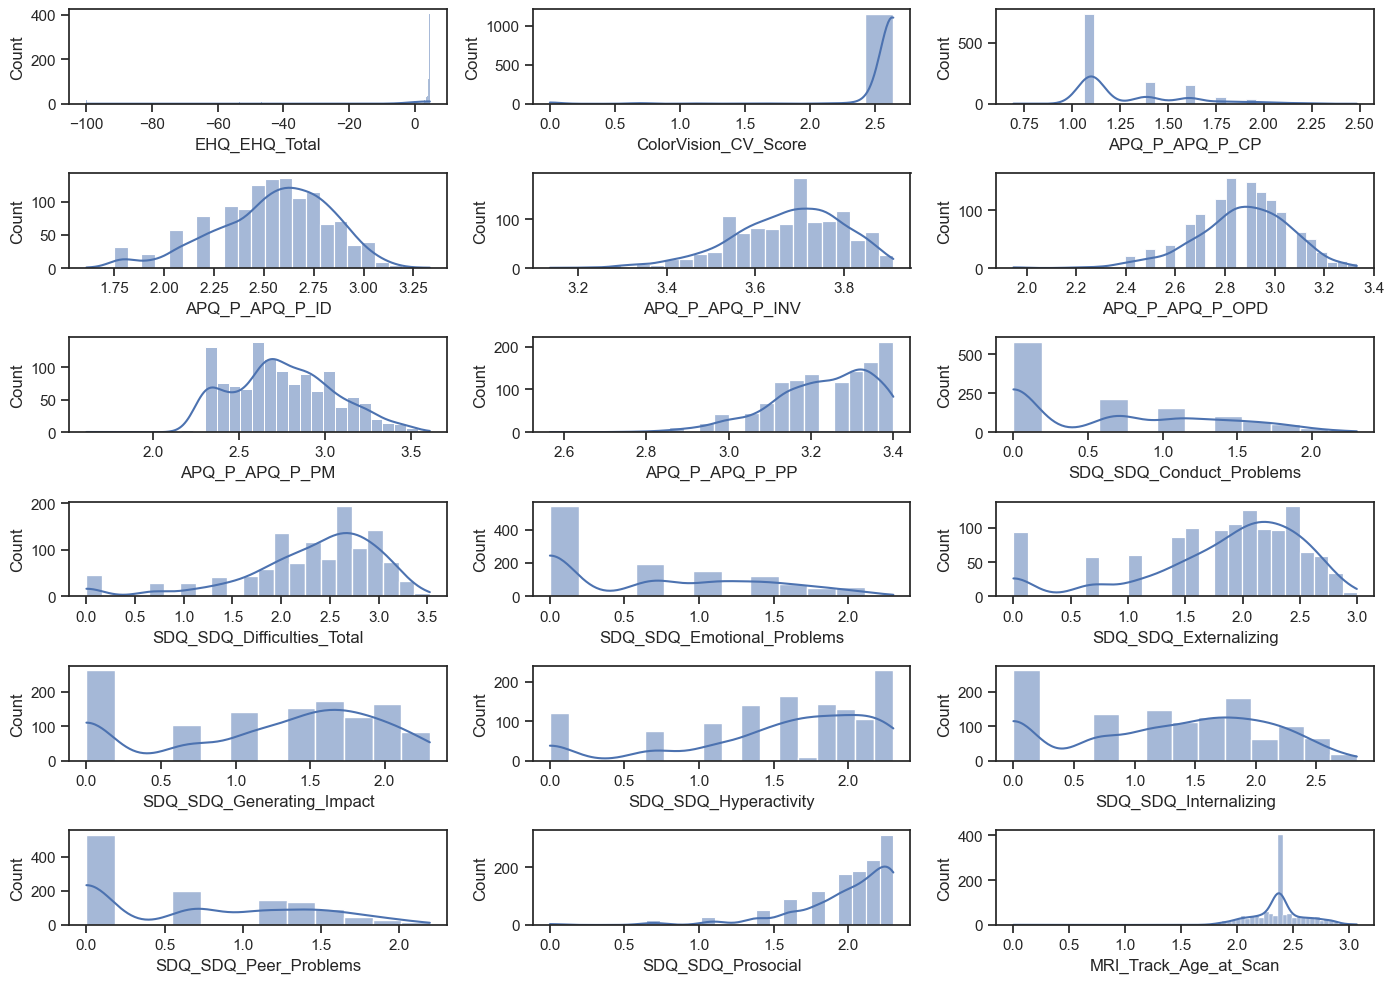

In [48]:
#first method - log transformation
log_quant = imputed_quant_data.applymap(lambda x: np.log(x) if x > 0 else x)

plt.figure(figsize=(14, 10))
for i, var in enumerate(quant_variables):
    plt.subplot(6, 3, i+1)
    sns.histplot(log_quant[var], kde=True)
plt.tight_layout()
plt.show()

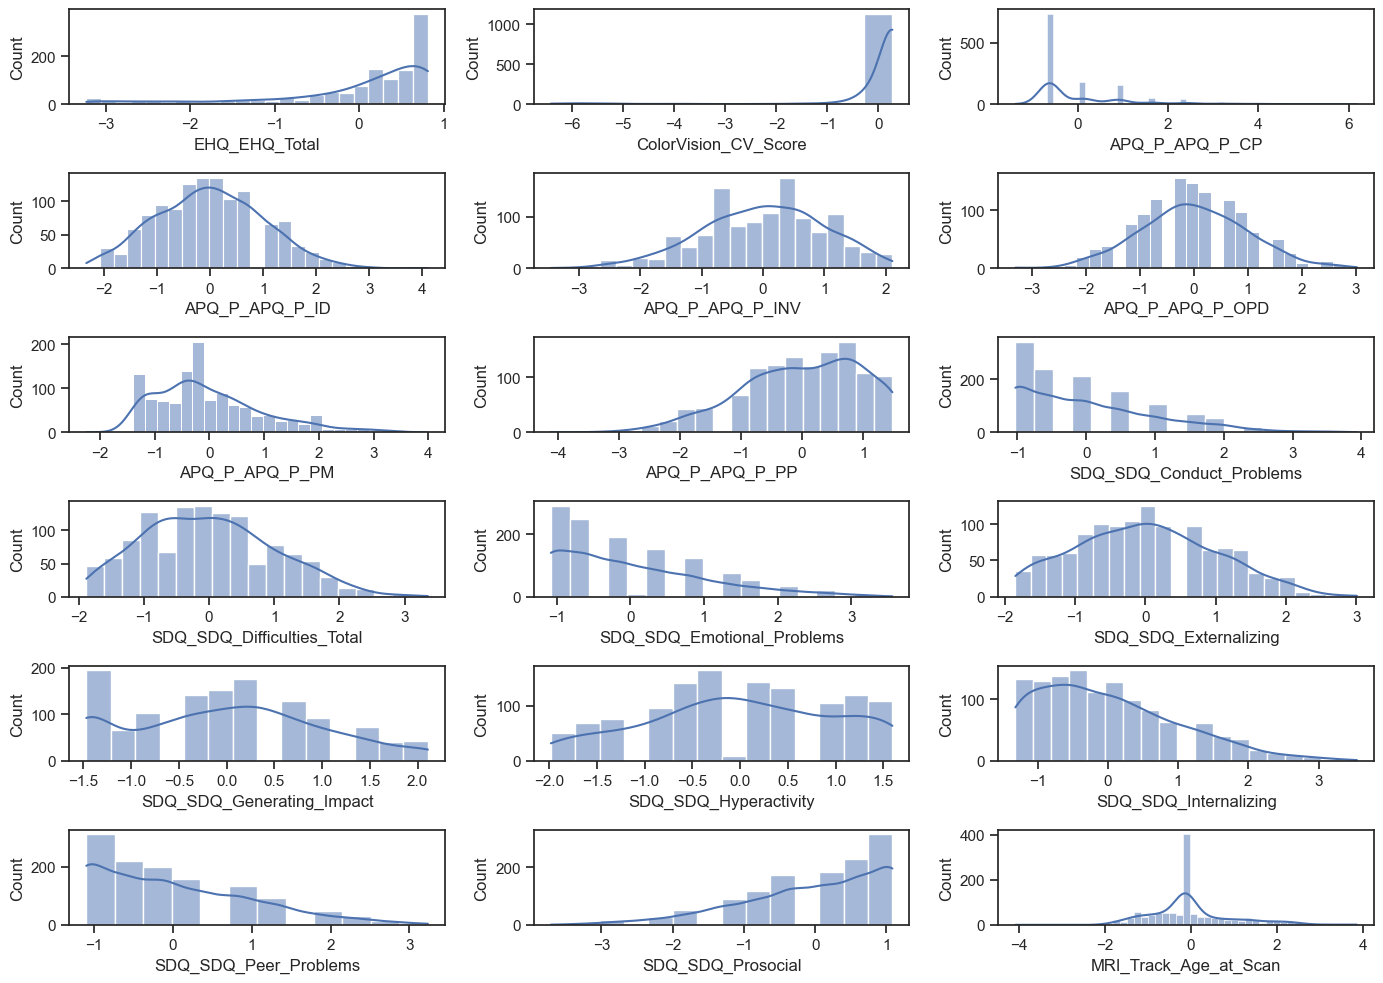

In [49]:
#second method - standardization
scaler = StandardScaler()
scaled_quant_data = scaler.fit_transform(imputed_quant_data[quant_variables])
scaled_quant_df = pd.DataFrame(scaled_quant_data, columns=quant_variables)

plt.figure(figsize=(14, 10))
for i, var in enumerate(quant_variables):
    plt.subplot(6, 3, i+1)
    sns.histplot(scaled_quant_df[var], kde=True)
plt.tight_layout()
plt.show()

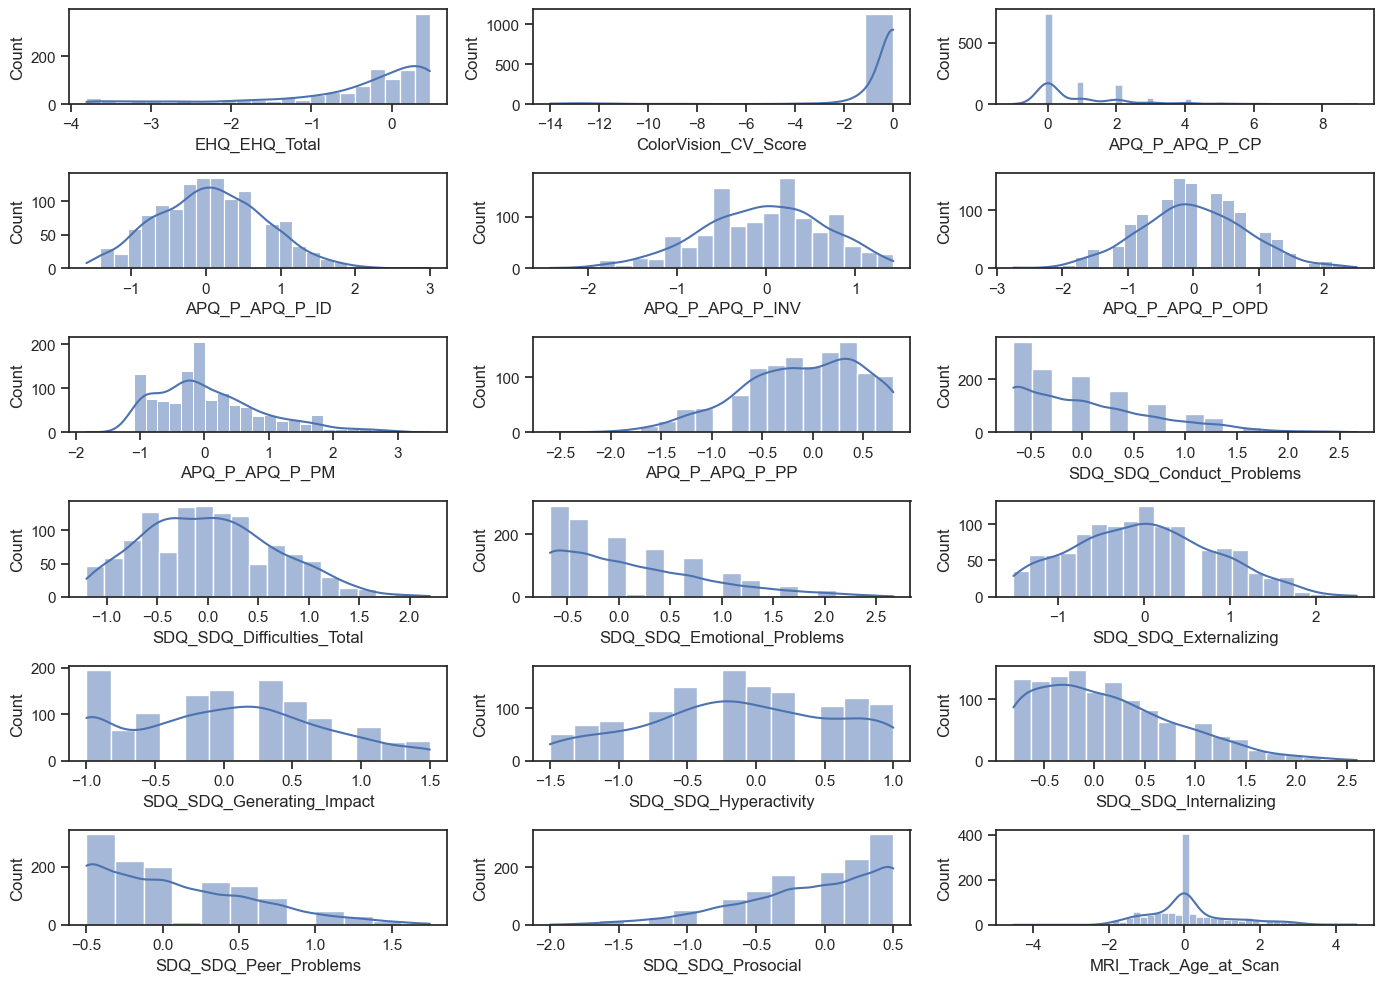

In [50]:
#third method - robust scaler (address outliers)
robust_scaler = RobustScaler()
robust_scaled_data = robust_scaler.fit_transform(imputed_quant_data[quant_variables])
scaled_df = pd.DataFrame(robust_scaled_data, columns=quant_variables)

plt.figure(figsize=(14, 10))
for i, var in enumerate(quant_variables):
    plt.subplot(6, 3, i+1)
    sns.histplot(scaled_df[var], kde=True)
plt.tight_layout()
plt.show()

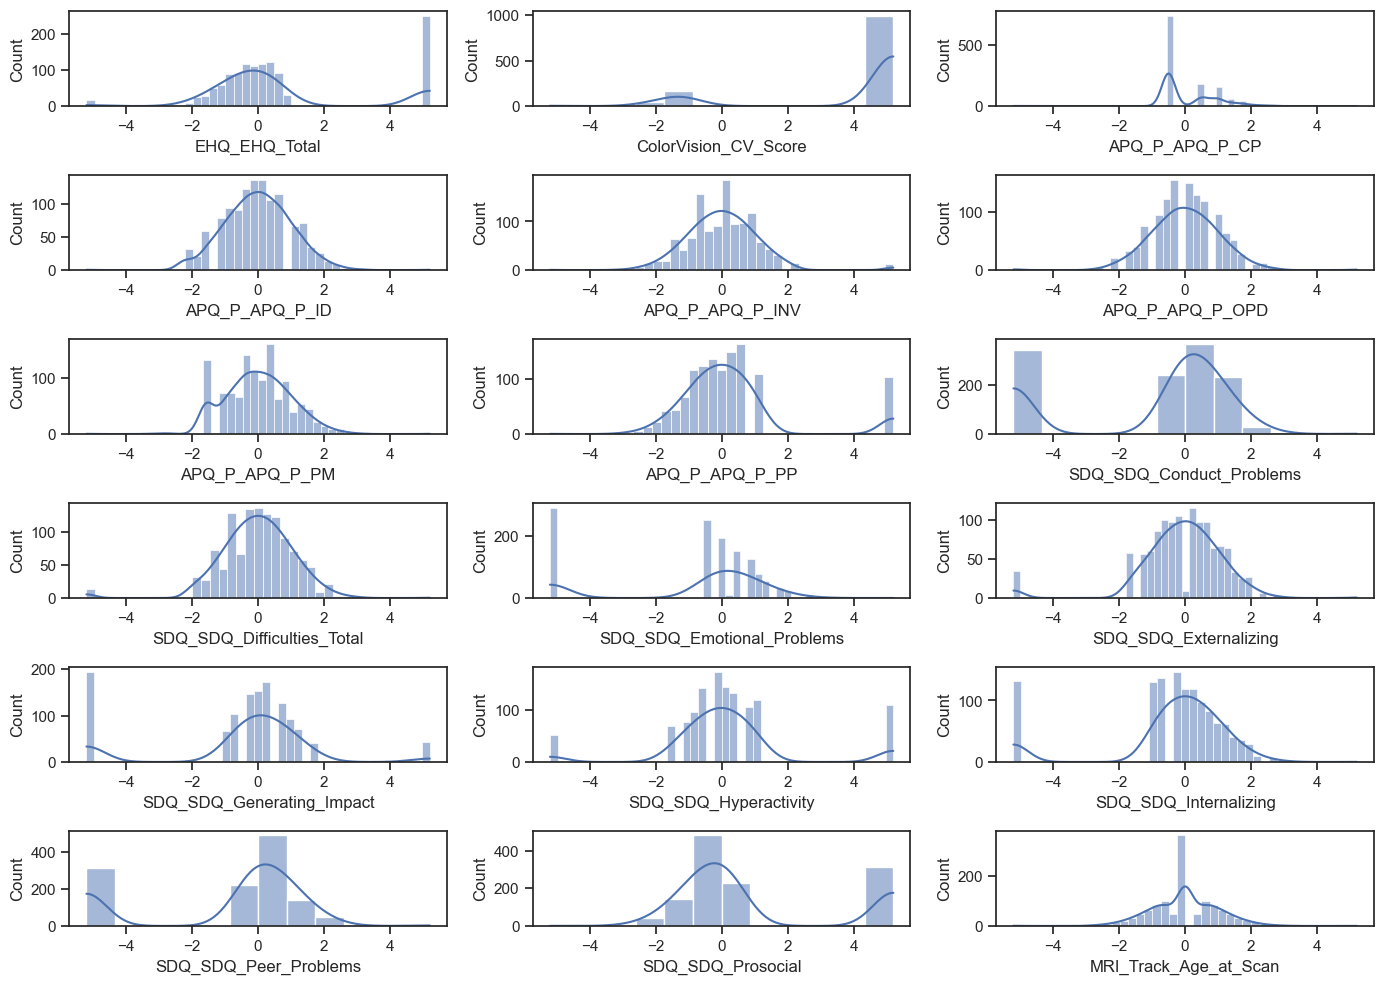

In [51]:
#fourth method - quantile transformation - scale data into normal distribution
qt = QuantileTransformer(output_distribution='normal').fit(imputed_quant_data[quant_variables])
quantile_transform = qt.transform(imputed_quant_data[quant_variables])
qt_df = pd.DataFrame(quantile_transform, columns=quant_variables)

plt.figure(figsize=(14, 10))
for i, var in enumerate(quant_variables):
    plt.subplot(6, 3, i+1)
    sns.histplot(qt_df[var], kde=True)
plt.tight_layout()
plt.show()

In [173]:
scaled_quant_final = pd.concat([quant_data.drop(columns=quant_variables), scaled_df], axis=1) 
#final scaling method is robust scaler since this project will focus on using tree-based model which can work well with skewed data

In [191]:
#mri_transform
mri_df = mri_data.drop(columns='participant_id')
scaled_mri = scaler.fit_transform(mri_df)
scaled_mri_df = pd.DataFrame(scaled_mri, columns=mri_df.columns)

scaled_mri_final = pd.concat([mri_data.drop(columns=mri_df.columns), scaled_mri_df], axis=1) 

### Combine dataset

In [193]:
data_df = pd.merge(scaled_quant_final, scaled_mri_final, on='participant_id')
train_df = pd.merge(data_df, cat_encoded_final, on='participant_id')
df = pd.merge(train_df, y_data, on="participant_id")

X_train = df.drop(columns=['participant_id', 'Sex_F', "ADHD_Outcome"])
y_train = df[['Sex_F', "ADHD_Outcome"]]

### Class imbalance problem

In [194]:
# Gender distribution
y_train['Sex_F'].value_counts()

0    797
1    416
Name: Sex_F, dtype: int64

In [195]:
# ADHD Distribution
y_train['ADHD_Outcome'].value_counts(normalize=True)

1    0.685078
0    0.314922
Name: ADHD_Outcome, dtype: float64

In [196]:
from imblearn.over_sampling import SMOTE

In [197]:
#Upsampling
df_resampled = df.copy()

# Combine the two targets into a single label
df_resampled['combined_target'] = df_resampled['Sex_F'].astype(str) + "_" + df_resampled["ADHD_Outcome"].astype(str)

# Apply SMOTE
smote = SMOTE(random_state=2025)
X_resampled, y_resampled = smote.fit_resample(df_resampled.drop(columns=["participant_id",'combined_target']), df_resampled['combined_target'])

df_upsampled = X_resampled

In [198]:
df_upsampled['Sex_F'].value_counts()

0    1162
1    1162
Name: Sex_F, dtype: int64

In [199]:
df_upsampled['ADHD_Outcome'].value_counts()

1    1162
0    1162
Name: ADHD_Outcome, dtype: int64

In [200]:
pd.crosstab(df_upsampled['Sex_F'], df_upsampled['ADHD_Outcome'])

ADHD_Outcome,0,1
Sex_F,,
0,581,581
1,581,581


In [201]:
X_upsampled = df_upsampled.drop(columns=['Sex_F', "ADHD_Outcome"])
y_upsampled = df_upsampled[['Sex_F', "ADHD_Outcome"]]

### Spliting train set and validation set 

In [202]:
X_train_1, X_val, y_train_1, y_val = train_test_split(X_upsampled, 
                                                      y_upsampled, 
                                                      test_size=0.25, 
                                                      random_state=2025)

## Models

### Full model

In [63]:
def multi_output_f1(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute f1 score for each target variable and return the mean
    return np.mean([f1_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])

multi_output_scorer = make_scorer(multi_output_f1)

In [64]:
#logistic regression
log_model = LogisticRegression(max_iter=1000, random_state=2025, class_weight='balanced')
model_1 = MultiOutputClassifier(log_model) 

In [66]:
cv_model = cross_val_score(model_1, 
                           X_upsampled, 
                           y_upsampled, 
                           cv=5, scoring=multi_output_scorer) #model with full independent variables

print("Cross-validation scores for each fold:", cv_model)
print("Mean CV score:", np.mean(cv_model))

/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


Cross-validation scores for each fold: [0.85332652 0.86627596 0.86311014 0.5        1.        ]
Mean CV score: 0.8165425239131757


### Feature selection

In [209]:
#Lasso regulation is used to eliminate zero coefficients i.e., non-important variables 

l1_model_1 = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=2025)
l1_model_1.fit(X_train_1, y_train_1['Sex_F'])

selected_features_Sex = X_train_1.columns[l1_model_1.coef_[0] != 0]
print(selected_features_Sex)

Index(['ColorVision_CV_Score', 'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_INV',
       'APQ_P_APQ_P_PP', 'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Prosocial', '0throw_3thcolumn', '0throw_4thcolumn',
       '0throw_27thcolumn',
       ...
       '184throw_198thcolumn', '187throw_196thcolumn', '187throw_198thcolumn',
       '189throw_194thcolumn', '190throw_192thcolumn', '191throw_192thcolumn',
       '191throw_197thcolumn', '193throw_199thcolumn',
       'Barratt_Barratt_P1_Edu_18.0', 'Barratt_Barratt_P2_Occ_45.0'],
      dtype='object', length=845)


In [210]:
l1_model_2 = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=2025)
l1_model_2.fit(X_train_1, y_train_1['ADHD_Outcome'])

selected_features_ADHD = X_train_1.columns[l1_model_2.coef_[0] != 0]
print(selected_features_ADHD)

Index(['SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
       'SDQ_SDQ_Internalizing', 'MRI_Track_Age_at_Scan', '0throw_21thcolumn',
       '0throw_58thcolumn', '0throw_59thcolumn', '0throw_102thcolumn',
       ...
       '185throw_187thcolumn', '185throw_190thcolumn', '187throw_198thcolumn',
       '194throw_199thcolumn', '196throw_198thcolumn', '198throw_199thcolumn',
       'Barratt_Barratt_P1_Edu_18.0', 'Barratt_Barratt_P1_Edu_21.0',
       'Barratt_Barratt_P1_Occ_35.0', 'Barratt_Barratt_P2_Edu_21.0'],
      dtype='object', length=742)


In [211]:
combined_features = list(set(selected_features_ADHD).union(set(selected_features_Sex)))
len(combined_features)

1554

### Models

In [70]:
def multi_output_scores(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute f1 score for each target variable and return the mean
    print("Mean f1 score", np.mean([f1_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]))
    print("Mean accuracy score", np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]))
    print("Mean precision score", np.mean([precision_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]))
    print("Mean recall score", np.mean([recall_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]))

#### Logistic regression

In [71]:
cv_model_1 = cross_val_score(model_1, 
                             X_upsampled[combined_features], 
                             y_upsampled, cv=5, 
                             scoring=multi_output_scorer)

print("Cross-validation scores for each fold:", cv_model_1)
print("Mean CV score:", np.mean(cv_model_1)) #seem to get overfitting problem 

/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1609: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


Cross-validation scores for each fold: [0.91980612 0.91622599 0.92442317 0.5        0.99924357]
Mean CV score: 0.851939770323256


In [72]:
#logistic regression
model_1.fit(X_train_1[combined_features], y_train_1)
y_pred = model_1.predict(X_val[combined_features]) #overfitting 

multi_output_scores(y_val, y_pred)

Mean f1 score 0.8925752526410944
Mean accuracy score 0.8993115318416524
Mean precision score 0.9092104526887136
Mean recall score 0.8776074259491031


In [73]:
common_features = list(set(selected_features_ADHD) & set(selected_features_Sex))

cv_model_2 = cross_val_score(model_1, 
                             X_upsampled[common_features], 
                             y_upsampled, 
                             cv=5, scoring=multi_output_scorer)

print("Cross-validation scores for each fold:", cv_model_2)
print("Mean CV score:", np.mean(cv_model_2))

Cross-validation scores for each fold: [0.63908349 0.62833717 0.53989198 0.36406995 0.82151196]
Mean CV score: 0.5985789105331525


In [75]:
model_1.fit(X_train_1[common_features], y_train_1)
pred = model_1.predict(X_val[common_features]) #overfitting 

multi_output_scores(y_val, pred)

Mean f1 score 0.72587449436635
Mean accuracy score 0.7314974182444063
Mean precision score 0.7109918810640887
Mean recall score 0.7421646850229453


#### XGBoost

In [203]:
# Initialize the base classifier
xgb_classifier_1 = XGBClassifier(objective='binary:logistic', 
                                 n_estimators=700, 
                                 learning_rate=0.3, 
                                 max_depth=5, 
                                 random_state=0)

xgb_1 = MultiOutputClassifier(xgb_classifier_1) 

In [204]:
%%time 
xgb_1.fit(X_train_1[combined_features], y_train_1)

CPU times: user 1min 32s, sys: 19.5 s, total: 1min 52s
Wall time: 29.3 s


MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.3, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=700, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=0, ...))

In [205]:
pred_1 = xgb_1.predict(X_val[combined_features])
multi_output_scores(y_val, pred_1)

Mean f1 score 0.9056294827921056
Mean accuracy score 0.9113597246127367
Mean precision score 0.918415255404103
Mean recall score 0.8933693158114309


In [212]:
#continue to refine features for xgboost model
def multiple_model_ranking(model, X_data, y_data) :
    models = []
    importance_list = []

    for i in y_data.columns:  # say, 5 different models
        model.fit(X_data, y_data[i])
        models.append(model)

        # Extract importance (can use 'gain', 'weight', etc.)
        imp_dict = model.get_booster().get_score(importance_type='gain')

        # Convert to DataFrame
        imp_df = pd.DataFrame.from_dict(imp_dict, orient='index', columns=[f'importance_{i}'])
        importance_list.append(imp_df)

    # Merge all importance DataFrames
    importance_merged = pd.concat(importance_list, axis=1).fillna(0)

    # Compute mean importance across models
    importance_merged['mean_importance'] = importance_merged.mean(axis=1)

    # Rank features by mean importance
    importance_merged = importance_merged.sort_values(by='mean_importance', ascending=False)
    importance_merged['rank'] = range(1, len(importance_merged) + 1)

    # Reset index to get feature names as a column
    importance_ranked = importance_merged.reset_index().rename(columns={'index': 'Feature'})

    return importance_ranked[['Feature', 'mean_importance', 'rank']]

In [213]:
xgb_model = XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=2025)

importance_ranked = multiple_model_ranking(xgb_model, X_train_1[combined_features], y_train_1)

In [214]:
features_ranked = importance_ranked['Feature']

selected_quant_feature = ['SDQ_SDQ_Conduct_Problems',
       'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Emotional_Problems',
       'SDQ_SDQ_Externalizing', 'SDQ_SDQ_Generating_Impact',
       'SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Internalizing',
       'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial', 'APQ_P_APQ_P_INV']

features_1 = list(set(features_ranked).union(set(selected_quant_feature)))
len(features_1)

1328

In [163]:
xgb = XGBClassifier(objective='binary:logistic', random_state=0) 

cv_params = {'max_depth': [5,6], 
             'learning_rate': [0.2, 0.3],
             'n_estimators': [500, 700]
             }    

scoring = multi_output_scorer

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5)

In [83]:
%%time
#xgb_cv.fit(X_train_1[features_1], y_train_1)

CPU times: user 7 µs, sys: 2 µs, total: 9 µs
Wall time: 16.9 µs


In [84]:
#xgb_cv.best_score_

In [85]:
#xgb_cv.best_params_

In [86]:
cv_params_2 = {'max_depth': [5], 
             'learning_rate': [0.2],
             'n_estimators': [700],
               'subsample' : [0.5, 0.6, 0.7]
             }    

xgb_cv_2 = GridSearchCV(xgb, cv_params_2, scoring=scoring, cv=5)

In [87]:
%%time
#xgb_cv_2.fit(X_train_1[features_1], y_train_1)

CPU times: user 5 µs, sys: 2 µs, total: 7 µs
Wall time: 13.1 µs


In [88]:
#xgb_cv_2.best_params_

In [89]:
#xgb_cv_2.best_score_

In [215]:
# Initialize the classifier
xgb_classifier_2 = XGBClassifier(objective='binary:logistic', 
                                 n_estimators=700, 
                                 learning_rate=0.2, 
                                 max_depth=5,
                                 subsample=0.5,
                                 scale_pos_weight = 0.9,
                                 random_state=2025) #chosen based on Grid Search CV

xgb_2 = MultiOutputClassifier(xgb_classifier_2) 

In [216]:
%%time 
xgb_2.fit(X_train_1[features_1], y_train_1)

CPU times: user 2min 8s, sys: 23.3 s, total: 2min 31s
Wall time: 47.5 s


MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.2, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=700, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=2025, ...))

In [217]:
pred_2 = xgb_2.predict(X_val[features_1])

multi_output_scores(y_val, pred_2)

Mean f1 score 0.9070711896798853
Mean accuracy score 0.9122203098106713
Mean precision score 0.9155717761557178
Mean recall score 0.8990143929912391


#### Random forest

In [93]:
rf = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [4, 5], 
             'min_samples_leaf': [2, 3],
             'min_samples_split': [2, 3],
             'n_estimators': [500, 600, 700]
             }  

scoring = multi_output_scorer

rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5)

In [94]:
%%time
#rf_cv.fit(X_train_1[features_1], y_train_1)

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 6.91 µs


In [95]:
#rf_cv.best_params_

In [96]:
#rf_cv.best_score_

In [97]:
rf = RandomForestClassifier(max_depth= 5, 
                            min_samples_leaf= 3,
                            min_samples_split=2,
                            n_estimators= 600,
                            random_state=0, 
                            class_weight='balanced')

rf_model = MultiOutputClassifier(rf) 

In [98]:
%%time 
rf_model.fit(X_train_1[features_1], y_train_1)

CPU times: user 25.2 s, sys: 28.2 ms, total: 25.3 s
Wall time: 25.3 s


MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                       max_depth=5,
                                                       min_samples_leaf=3,
                                                       n_estimators=600,
                                                       random_state=0))

In [99]:
rf_pred = rf_model.predict(X_val[features_1])
multi_output_scores(y_val, rf_pred) 

Mean f1 score 0.8683903185534212
Mean accuracy score 0.8760757314974182
Mean precision score 0.8814442969355016
Mean recall score 0.855744159365874


### Dimensionality reduction

In [100]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from matplotlib.ticker import MaxNLocator

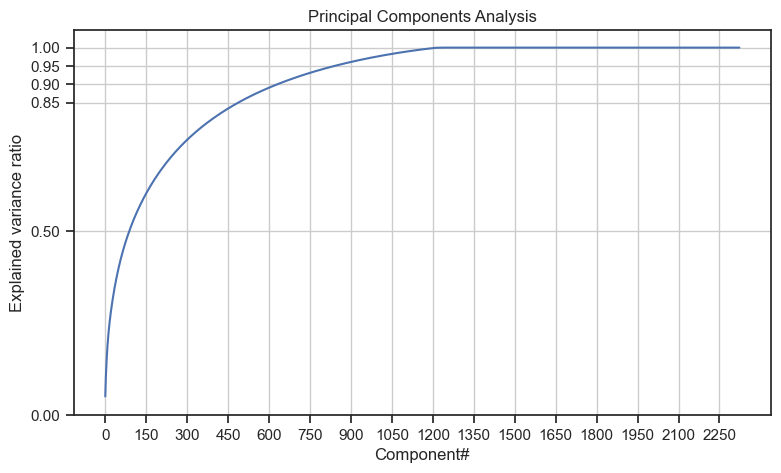

In [101]:
pca = make_pipeline(PCA())
pca.fit(X_upsampled[X_upsampled.columns])

plt.figure(figsize=(9,5))
plt.plot(pca[-1].explained_variance_ratio_.cumsum())
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Principal Components Analysis')
plt.xlabel('Component#')
plt.ylabel('Explained variance ratio')
plt.yticks([0,0.5,0.85,0.90,0.95,1])
plt.xticks(range(0,2400,150))
plt.grid()
plt.show()

#### Logistic regression

In [102]:
#logistic regression
log_model = LogisticRegression(max_iter=1000, random_state=2025, class_weight='balanced')

model_pca = MultiOutputClassifier(make_pipeline(PCA(700), log_model)) 

model_pca.fit(X_train_1, y_train_1)
log_pred = model_pca.predict(X_val) 

multi_output_scores(y_val, log_pred)

Mean f1 score 0.9039281863779122
Mean accuracy score 0.9096385542168675
Mean precision score 0.9167424242424242
Mean recall score 0.8921177513558615


#### XGBoost

In [103]:
# Initialize the base classifier
xgb_classifier = XGBClassifier(objective='binary:logistic', 
                                 n_estimators=700, 
                                 learning_rate=0.2, 
                                 max_depth=6,
                                 subsample=0.5,
                                 scale_pos_weight = 0.9,
                                 random_state=0)

xgb_pca = MultiOutputClassifier(make_pipeline(PCA(700), xgb_classifier)) #xgb with pca

In [104]:
%%time 
xgb_pca.fit(X_train_1, y_train_1)

CPU times: user 4min 4s, sys: 19.6 s, total: 4min 23s
Wall time: 1min 21s


MultiOutputClassifier(estimator=Pipeline(steps=[('pca', PCA(n_components=700)),
                                                ('xgbclassifier',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               callbacks=None,
                                                               colsample_bylevel=None,
                                                               colsample_bynode=None,
                                                               colsample_bytree=None,
                                                               device=None,
                                                               early_stopping_rounds=None,
                                                               enable_categorical=False,
                                                               eval_metric=None,
                                                               feature_types=None,
                                                               gamma=None,
                                                               grow_policy=None,
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=0.2,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=6,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=700,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=0, ...))]))

In [105]:
xgb_pred_1 = xgb_pca.predict(X_val)
multi_output_scores(y_val, xgb_pred_1)

Mean f1 score 0.8565196998123826
Mean accuracy score 0.8648881239242685
Mean precision score 0.8713617751217353
Mean recall score 0.8453014184397163


#### Random forest

In [106]:
rf = RandomForestClassifier(max_depth= 5, 
                            min_samples_leaf= 3,
                            min_samples_split=2,
                            n_estimators= 600,
                            random_state=0)

rf_pca = MultiOutputClassifier(make_pipeline(PCA(700), rf)) 

In [107]:
%%time 
rf_pca.fit(X_train_1, y_train_1)

CPU times: user 3min 10s, sys: 9.61 s, total: 3min 19s
Wall time: 1min 16s


MultiOutputClassifier(estimator=Pipeline(steps=[('pca', PCA(n_components=700)),
                                                ('randomforestclassifier',
                                                 RandomForestClassifier(max_depth=5,
                                                                        min_samples_leaf=3,
                                                                        n_estimators=600,
                                                                        random_state=0))]))

In [108]:
rf_pred_1 = rf_pca.predict(X_val)
multi_output_scores(y_val, rf_pred_1) 

Mean f1 score 0.6839929910758467
Mean accuracy score 0.6824440619621343
Mean precision score 0.647985347985348
Mean recall score 0.7246297455152273
